# **All analyzes for sex-differences paper** 

### Dependencies

In [238]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import (shapiro, ttest_ind, mannwhitneyu, pearsonr)
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor
import os
import umap.umap_ as umap
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
from scipy.stats import chi2_contingency
import matplotlib.ticker as ticker
 
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import pingouin as pg
from matplotlib.lines import Line2D


In [239]:
# Data preparation
def format_stats(group, col):
    stats = group[col].agg(['mean', 'std', 'min', 'max'])
    return {
        'M (SD)': f"{stats['mean']:.2f} ({stats['std']:.2f})",
        'Range (Min-Max)': f"{stats['min']:.2f} to {stats['max']:.2f}"
    }

# Create the table structure
def create_descriptive_table(df, class_column, vars_to_include):
    result_data = []
    
    # Group unique classes
    class_groups = df[class_column].unique()
    
    for group_name in class_groups:
        group_data = df[df[class_column] == group_name]
        row_data = {
            'Classification': class_column,
            'Group': f"Group {group_name}",
            'n': len(group_data)
        }
        
        # Calculate stats for each variable
        for var in vars_to_include:
            stats = format_stats(group_data, var)
            row_data[f"{var} M (SD)"] = stats['M (SD)']
            row_data[f"{var} Range"] = stats['Range (Min-Max)']
        
        result_data.append(row_data)
    
    return pd.DataFrame(result_data)

# Create helper function for chi-square tests and reporting
def perform_chi_square(df, group_var, demo_var):
    """
    Perform chi-square test and return formatted results
    """
    # Create contingency table
    contingency = pd.crosstab(df[group_var], df[demo_var])
    
    # Calculate chi-square
    chi2, p, dof, expected = chi2_contingency(contingency)
    
    # Calculate Cramer's V for effect size
    n = contingency.sum().sum()
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))
    
    # Calculate standardized residuals
    observed = contingency.values
    standardized_residuals = (observed - expected) / np.sqrt(expected)
    
    return {
        'contingency': contingency,
        'chi2': chi2,
        'p': p,
        'dof': dof,
        'cramers_v': cramers_v,
        'residuals': standardized_residuals
    }

# Function to create a table with demographic information
def create_demographic_table(df, stratification_methods, demographic_vars):
    """
    Creates a table with demographic counts, percentages, and chi-square results
    """
    result_tables = {}
    
    for method in stratification_methods:
        method_results = {}
        for demo in demographic_vars:
            # Get counts and percentages
            counts = pd.crosstab(df[method], df[demo])
            percentages = pd.crosstab(df[method], df[demo], normalize='index') * 100
            
            # Perform chi-square
            chi_result = perform_chi_square(df, method, demo)
            
            # Store results
            method_results[demo] = {
                'counts': counts,
                'percentages': percentages,
                'chi2': chi_result['chi2'],
                'p': chi_result['p'],
                'cramers_v': chi_result['cramers_v']
            }
        
        result_tables[method] = method_results
    
    return result_tables

# Function to generate  figures
def create_demographic_plots(df, stratification_methods, demographic_vars, filename=None):
    """
    Creates publication-ready plots for demographic variables
    """
    # Set up figure
    n_methods = len(stratification_methods)
    n_demos = len(demographic_vars)
    
    # Set up a nice color palette
    colors = sns.color_palette("Paired", max(3, max([len(df[demo].unique()) for demo in demographic_vars])))
    
    # Create figure with two rows (one for each method) and columns for each demographic
    fig, axes = plt.subplots(n_methods, n_demos, figsize=(4*n_demos, 4*n_methods))
    
    # If there's only one demo variable, wrap axes in a list
    if n_demos == 1:
        axes = np.array([axes]).reshape(n_methods, 1)
    
    for i, method in enumerate(stratification_methods):
        for j, demo in enumerate(demographic_vars):
            ax = axes[i, j]
            
            # Get chi-square results
            chi_result = perform_chi_square(df, method, demo)
            
            # Create the plot
            if demo == "NVIQ":  # Continuous variable handling
                sns.boxplot(x=method, y=demo, data=df, palette=colors[:len(df[method].unique())], ax=ax)
                # For IQ, we'd use ANOVA instead of chi-square
                # Perform ANOVA and get F-statistic and p-value


                #f_stat, p_val = sm.stats.anova_lm(sm.formula.ols(f"{demo} ~ C('{method}')", data=df).fit())['F'][0], sm.formula.anova_lm(sm.formula.ols(f"{demo} ~ C('{method}')", data=df).fit())['PR(>F)'][0]
                #ax.set_title(f"{demo} by {method}\nF={f_stat:.2f}, p={p_val:.3f}")
            else:
                # For categorical variables, normalize within each class
                # and create stacked percentage bars
                prop_data = pd.crosstab(df[method], df[demo], normalize='index')
                prop_data.plot(kind='bar', stacked=True, ax=ax, color=colors[:len(df[demo].unique())])
                
                # Add chi-square result to title
                ax.set_title(f"{demo} by {method}\nχ²={chi_result['chi2']:.2f}, p={chi_result['p']:.3f}")
                
                # Add percentage labels to bars
                for container in ax.containers:
                    ax.bar_label(container, label_type='center', fmt='%.2f', fontsize=8)
                
                # Adjust y-axis to make room for labels
                ax.set_ylim(0, 1.1)
            
            # Formatting
            ax.set_xlabel(method)
            if j == 0:  # Only show y-label for first column
                ax.set_ylabel("Percentage" if demo != "NVIQ" else "IQ")
            else:
                ax.set_ylabel("")
            ax.legend(ncol=min(3, len(df[demo].unique())),  # Max 3 columns
                bbox_to_anchor=(0.5, -0.2),  # Below plot
                loc='upper center',
            frameon=False)
    
    plt.tight_layout()
    
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
    
    return fig


# Generate tables as DataFrames
def format_table_for_publication(demo_tables):
    """
    Format demographic results into publication-ready tables
    """
    publication_tables = {}
    
    for method, method_data in demo_tables.items():
        # Create a list to store rows
        rows = []
        
        for demo, demo_data in method_data.items():
            # Add header row for demographic variable
            rows.append({
                'Variable': f"**{demo}**",
                'Statistics': '',
                'Chi-square': '',
                'p-value': '',
                "Cramer's V": ''
            })
            
            # Add data rows
            counts = demo_data['counts']
            percentages = demo_data['percentages']
            
            for category in counts.columns:
                row_data = {
                    'Variable': f"  {category}",
                    'Statistics': 'n (%)',
                }
                
                # Add counts and percentages for each class
                for cls in counts.index:
                    count = counts.loc[cls, category]
                    percent = percentages.loc[cls, category]
                    row_data[f'Class {cls[-1] if cls in hc_order else cls}'] = f"{count} ({percent:.1f}%)"
                
                # Add chi-square info only for first category row
                if category == counts.columns[0]:
                    row_data['Chi-square'] = f"{demo_data['chi2']:.2f}"
                    row_data['p-value'] = f"{demo_data['p']:.3f}"
                    row_data["Cramer's V"] = f"{demo_data['cramers_v']:.3f}"
                
                rows.append(row_data)
        
        # Convert to DataFrame
        publication_tables[method] = pd.DataFrame(rows)
    
    return publication_tables

def calculate_p_values(df):
    """Calculate p-values for correlations in a dataframe, handling NAs"""
    p_values = pd.DataFrame(index=df.columns, columns=df.columns)
    for i in range(len(df.columns)):
        for j in range(len(df.columns)):
            if i != j:
                # Get the columns and drop NA values for valid comparison
                col1 = df.iloc[:, i]
                col2 = df.iloc[:, j]
                
                # Create a mask of non-NA values in both columns
                valid_mask = ~(col1.isna() | col2.isna())
                
                # Only calculate correlation if we have enough valid data points
                if valid_mask.sum() > 1:  # Need at least 2 points for correlation
                    _, p_value = pearsonr(col1[valid_mask], col2[valid_mask])
                    p_values.iloc[i, j] = p_value
                else:
                    p_values.iloc[i, j] = np.nan
            else:
                p_values.iloc[i, j] = 0  # Set diagonal to 0
    return p_values

def plot_correlation_matrix(corr_matrix, p_values, title, significance_method='bold'):
    """Create correlation heatmap with highlighted significant correlations
    
    Parameters:
    -----------
    corr_matrix : pandas DataFrame
        The correlation matrix to plot
    p_values : pandas DataFrame
        Matrix of p-values corresponding to correlations
    title : str
        Title for the plot
    significance_method : str
        Method to highlight significant correlations:
        - 'bold': Use bold text for significant correlations
        - 'border': Add black border around significant cells
        - 'intense': Use more intense colors for significant correlations
    """
    plt.figure(figsize=(12, 10))
    
    # Create mask for upper triangle
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    # Create the base heatmap
    ax = sns.heatmap(
        corr_matrix, 
        annot=True, 
        cmap="coolwarm", 
        center=0, 
        vmin=-1, 
        vmax=1, 
        square=True, 
        mask=mask,
        fmt=".2f",
        annot_kws={"size": 9}
    )
    
    # Create a custom annotation function for significant values
    #  
    if significance_method == 'bold' or significance_method == 'size':
        # Get all text elements from the heatmap
        # Create a new set of annotations for significant values
        for i in range(len(corr_matrix)):
            for j in range(len(corr_matrix.columns)):
                # Only process cells in the lower triangle
                if i > j:  # Lower triangle only
                    is_significant = (not np.isnan(p_values.iloc[i, j]) and 
                                     p_values.iloc[i, j] < 0.05)
                    
                    if is_significant:
                        value = corr_matrix.iloc[i, j]
                        if significance_method == 'bold':
                            # Add a bold text annotation
                            ax.text(j + 0.5, i + 0.5, f"{value:.2f}", 
                                   ha='center', va='center', 
                                   fontweight='bold', color='black',
                                   fontsize=8)
                        elif significance_method == 'size':
                            # Add a larger text annotation
                            ax.text(j + 0.5, i + 0.5, f"{value:.2f}", 
                                   ha='center', va='center', 
                                   color='black', fontsize=12)
    
    # Add borders for significant cells
    elif significance_method == 'border':
        for i in range(len(corr_matrix)):
            for j in range(len(corr_matrix.columns)):
                if i > j:  # Lower triangle only
                    is_significant = (not np.isnan(p_values.iloc[i, j]) and 
                                     p_values.iloc[i, j] < 0.05)
                    
                    if is_significant:
                        # Add border around significant cells
                        ax.add_patch(Rectangle((j, i), 1, 1, fill=False, 
                                              edgecolor='gray', lw=2))
    
    #  
    #  
    
    # Add p-value significance legend
    legend_text = {
        'bold': "Bold values indicate p < 0.05",
        'size': "Larger values indicate p < 0.05",
        'border': "Cells with gray borders indicate p < 0.05"
    }
    plt.figtext(0.5, 0.001, legend_text.get(significance_method, 
                                          "Highlighted cells indicate p < 0.05"), 
               ha="center")
    
    plt.title(title, fontsize=14, pad=20)
    plt.tight_layout()
    
    return ax


In [240]:
# Function to perform outlier removal using IQR
def handle_outliers_iqr(df, var):
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_filtered = df[(df[var] >= lower_bound) & (df[var] <= upper_bound)]
    return df_filtered

# **Data setup:** Load data

In [241]:
main_df = pd.read_csv(f"../../datasets/sex_diff_main.csv") 

In [242]:
main_df.columns

Index(['subject', 'front_gamma_6', 'front_gamma_12', 'front_gamma_18',
       'dmn_con_6', 'dmn_con_12', 'attn_con_6', 'attn_con_12', 'visual_con_6',
       'visual_con_12', 'auditory_con_6', 'auditory_con_12', 'lang_comp_con_6',
       'lang_comp_con_12', 'speech_con_6_left', 'speech_con_12_left',
       'gamma_lat_6', 'gamma_lat_12', 'gamma_lat_18', 'site', 'group_type',
       'outcome', 'sex', 'hc_class', 'lpa_class', 'receptive_6',
       'expressive_6', 'receptive_12', 'expressive_12', 'receptive_18',
       'expressive_18', 'receptive_24', 'expressive_24', 'receptive_36',
       'expressive_36', 'nonverbal_iq_6'],
      dtype='object')

In [243]:
# Lannguage variables 
language_vars = ['receptive_6', 'expressive_6', 'receptive_12',
       'expressive_12', 'receptive_18', 'expressive_18', 'receptive_24',
       'expressive_24', 'receptive_36', 'expressive_36', 'nonverbal_iq_6']
cleaned_language_vars= ['Receptive MSEL 6 months', 'Expressive MSEL 6 months',
              'Receptive MSEL 12 months', 'Expressive MSEL 12 months',
              'Receptive MSEL 18 months', 'Expressive MSEL 18 months',
              'Receptive MSEL 24 months', 'Expressive MSEL 24 months',
              'Receptive MSEL 36 months', 'Expressive MSEL 36 months',
              'NVIQ']

In [244]:
# EEG variables — includes 12mo and 18mo frontal gamma / lateralization
eeg_vars = [
    'front_gamma_6', 'front_gamma_12', 'front_gamma_18',
    'dmn_con_6', 'dmn_con_12',
    'attn_con_6', 'attn_con_12',
    'visual_con_6', 'visual_con_12',
    'auditory_con_6', 'auditory_con_12',
    'lang_comp_con_6', 'lang_comp_con_12',
    'speech_con_6_left', 'speech_con_12_left',
    'gamma_lat_6', 'gamma_lat_12', 'gamma_lat_18',
]
clean_eeg_vars = [
    'Frontal Gamma Power 6mo', 'Frontal Gamma Power 12mo', 'Frontal Gamma Power 18mo',
    'DMN 6mo', 'DMN 12mo',
    'Attention Network 6mo', 'Attention Network 12mo',
    'Visual Network 6mo', 'Visual Network 12mo',
    'Auditory Network 6mo', 'Auditory Network 12mo',
    'Language Network 6mo', 'Language Network 12mo',
    'Speech Network 6mo', 'Speech Network 12mo',
    'Power Lateralization 6mo', 'Power Lateralization 12mo', 'Power Lateralization 18mo',
]


In [245]:
# Clean up column names
clean_column_name_mapping = {
  'expressive_6':  'Expressive MSEL 6 months',
  'expressive_12': 'Expressive MSEL 12 months',
  'expressive_18': 'Expressive MSEL 18 months',
  'expressive_24': 'Expressive MSEL 24 months',
  'expressive_36': 'Expressive MSEL 36 months',
  'receptive_6':   'Receptive MSEL 6 months',
  'receptive_12':  'Receptive MSEL 12 months',
  'receptive_18':  'Receptive MSEL 18 months',
  'receptive_24':  'Receptive MSEL 24 months',
  'receptive_36':  'Receptive MSEL 36 months',
  'nonverbal_iq_6': 'NVIQ',
  'lpa_class': 'LPA Class',
  'hc_class':  'HC Class',
  # EEG variables — frontal gamma at all 3 timepoints
  'front_gamma_6':  'Frontal Gamma Power 6mo',
  'front_gamma_12': 'Frontal Gamma Power 12mo',
  'front_gamma_18': 'Frontal Gamma Power 18mo',
  'dmn_con_6':  'DMN 6mo',
  'dmn_con_12': 'DMN 12mo',
  'attn_con_6':  'Attention Network 6mo',
  'attn_con_12': 'Attention Network 12mo',
  'visual_con_6':  'Visual Network 6mo',
  'visual_con_12': 'Visual Network 12mo',
  'auditory_con_6':  'Auditory Network 6mo',
  'auditory_con_12': 'Auditory Network 12mo',
  'lang_comp_con_6':  'Language Network 6mo',
  'lang_comp_con_12': 'Language Network 12mo',
  'speech_con_6_left':  'Speech Network 6mo',
  'speech_con_12_left': 'Speech Network 12mo',
  # Lateralization at all 3 timepoints
  'gamma_lat_6':  'Power Lateralization 6mo',
  'gamma_lat_12': 'Power Lateralization 12mo',
  'gamma_lat_18': 'Power Lateralization 18mo',
}

# Implement remapping
main_df.rename(columns=clean_column_name_mapping, inplace=True)


In [246]:
neurosubs_df=main_df.copy()

# **Descriptive statistics**

#### Demographics

In [247]:
# Total number of subjects
total_subjects = len(neurosubs_df)
total_subjects

179

##### Autism ASD Diagnosis 

In [248]:
neurosubs_df

,subject,Frontal Gamma Power 6mo,Frontal Gamma Power 12mo,Frontal Gamma Power 18mo,DMN 6mo,DMN 12mo,Attention Network 6mo,Attention Network 12mo,Visual Network 6mo,Visual Network 12mo,...,Expressive MSEL 6 months,Receptive MSEL 12 months,Expressive MSEL 12 months,Receptive MSEL 18 months,Expressive MSEL 18 months,Receptive MSEL 24 months,Expressive MSEL 24 months,Receptive MSEL 36 months,Expressive MSEL 36 months,NVIQ
0,2,-21.420116,-21.506803,-20.711995,-1.179456,-1.811397,-1.291220,-1.819618,NaN,-1.856955,...,5.0,13.0,13.0,22.0,14.0,28.0,21.0,NaN,NaN,7.0
1,3,-21.072590,-21.477770,-21.092442,-1.478355,-1.615233,-1.409049,-1.666511,-1.453274,-1.807008,...,7.0,14.0,14.0,20.0,18.0,27.0,21.0,NaN,NaN,6.5
2,5,-22.141673,-21.923702,NaN,-1.590910,-1.459731,-1.572270,-1.474575,-1.464652,-1.562207,...,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0
3,6,-21.630370,-21.010051,-21.793934,-1.613312,-1.636706,-1.519757,-1.629096,-1.398602,-1.597107,...,4.0,13.0,12.0,20.0,21.0,28.0,27.0,NaN,NaN,6.0
4,8,-21.588120,-22.242941,-22.352703,-1.573957,-1.732826,-1.582186,-1.682690,-1.650752,-1.743044,...,5.0,11.0,8.0,20.0,21.0,28.0,24.0,NaN,NaN,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,738,NaN,-21.061195,NaN,NaN,-1.724801,NaN,-1.756632,NaN,-1.476912,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
175,744,NaN,-20.921363,NaN,NaN,-1.469632,NaN,-1.493794,NaN,-1.494525,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
176,749,NaN,-21.403537,NaN,NaN,-1.605836,NaN,-1.578385,NaN,-1.699922,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
177,750,NaN,-20.462636,NaN,NaN,-1.536589,NaN,-1.525664,NaN,-1.570329,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [249]:
neurosubs_df["outcome"].value_counts()


outcome
no-asd    145
asd        30
Name: count, dtype: int64

##### Autism Risk 

In [250]:
neurosubs_df["group_type"].value_counts()

group_type
ELA    90
TLA    89
Name: count, dtype: int64

##### Site counts

In [251]:
neurosubs_df["site"].value_counts()
# We have a total of 99 in london and 83 in washington

site
london        96
washington    83
Name: count, dtype: int64

##### Sex differences

In [252]:
neurosubs_df[["sex"]].value_counts()


sex
M      91
F      88
Name: count, dtype: int64

##### Break down across variables

In [253]:
comprehensive_table=neurosubs_df.groupby(["group_type", "site", "sex", "outcome"]).outcome.value_counts().reset_index(name='count')
comprehensive_table = comprehensive_table.rename(columns={"group_type": "ASD Likelihood", "site": "Site", "sex":"Sex", "outcome":"ASD Diagnosis"})

# Save as supplementary table
comprehensive_table

,ASD Likelihood,Site,Sex,ASD Diagnosis,count
0,ELA,london,F,asd,5
1,ELA,london,F,no-asd,25
2,ELA,london,M,asd,11
3,ELA,london,M,no-asd,10
4,ELA,washington,F,asd,7
5,ELA,washington,F,no-asd,6
6,ELA,washington,M,asd,4
7,ELA,washington,M,no-asd,22
8,TLA,london,F,no-asd,27
9,TLA,london,M,no-asd,18


##### Demographics per sex

In [254]:
sex_comprehensive_table=neurosubs_df.groupby(["sex", "group_type","outcome"]).outcome.value_counts().reset_index(name='count')
sex_comprehensive_table = sex_comprehensive_table.rename(columns={"group_type": "ASD Likelihood", "site": "Site", "sex":"Sex", "outcome":"ASD Diagnosis"})

# Save as supplementary table
sex_comprehensive_table

,Sex,ASD Likelihood,ASD Diagnosis,count
0,F,ELA,asd,12
1,F,ELA,no-asd,31
2,F,TLA,asd,1
3,F,TLA,no-asd,43
4,M,ELA,asd,15
5,M,ELA,no-asd,32
6,M,TLA,asd,2
7,M,TLA,no-asd,39


##### Demographics per HC clustering group

In [255]:
hc_comprehensive_table=neurosubs_df.groupby(["sex", "group_type","outcome", "HC Class"]).outcome.value_counts().reset_index(name='count')
hc_comprehensive_table = hc_comprehensive_table.rename(columns={"group_type": "ASD Likelihood", "site": "Site", "sex":"Sex", "outcome":"ASD Diagnosis"})

# Save as supplementary table
hc_comprehensive_table

,Sex,ASD Likelihood,ASD Diagnosis,HC Class,count
0,F,ELA,asd,0.0,3
1,F,ELA,asd,1.0,2
2,F,ELA,asd,2.0,3
3,F,ELA,no-asd,0.0,3
4,F,ELA,no-asd,1.0,8
5,F,ELA,no-asd,2.0,12
6,F,TLA,asd,1.0,1
7,F,TLA,no-asd,0.0,13
8,F,TLA,no-asd,1.0,11
9,F,TLA,no-asd,2.0,11


##### Demographics per LPA clustering group

In [256]:
lpa_comprehensive_table=neurosubs_df.groupby(["sex", "group_type","outcome", "LPA Class"]).outcome.value_counts().reset_index(name='count')
lpa_comprehensive_table = lpa_comprehensive_table.rename(columns={"group_type": "ASD Likelihood", "site": "Site", "sex":"Sex", "outcome":"ASD Diagnosis"})

# Save as supplementary table
lpa_comprehensive_table

,Sex,ASD Likelihood,ASD Diagnosis,LPA Class,count
0,F,ELA,asd,1.0,3
1,F,ELA,asd,2.0,1
2,F,ELA,asd,3.0,4
3,F,ELA,no-asd,1.0,10
4,F,ELA,no-asd,2.0,2
5,F,ELA,no-asd,3.0,11
6,F,TLA,asd,3.0,1
7,F,TLA,no-asd,1.0,12
8,F,TLA,no-asd,2.0,8
9,F,TLA,no-asd,3.0,15


#### Participants demographics table

In [257]:
# Total sample size
total_n = len(neurosubs_df)

# Create a dictionary to store all the table data
table_data = {
    "Characteristic": [],
    "n": [],
    "%": []
}

# 1. Diagnostic Status
diag_counts = neurosubs_df['outcome'].value_counts()
table_data["Characteristic"].extend(["Diagnostic Status", "asd", "no-asd"])
table_data["n"].extend(["", diag_counts.get("asd", 0), diag_counts.get("no-asd", 0)])
table_data["%"].extend(["", 
                       round(diag_counts.get("asd", 0)/total_n*100, 1),
                       round(diag_counts.get("no-asd", 0)/total_n*100, 1)])

# 2. ASD Likelihood  
group_counts = neurosubs_df['group_type'].value_counts()
table_data["Characteristic"].extend(["ASD Likelihood", "TLA", "ELA"])
table_data["n"].extend(["", group_counts.get("TLA", 0), group_counts.get("ELA", 0)])
table_data["%"].extend(["", 
                       round(group_counts.get("TLA", 0)/total_n*100, 1),
                       round(group_counts.get("ELA", 0)/total_n*100, 1)])

# 3. Site
site_counts = neurosubs_df['site'].value_counts()
table_data["Characteristic"].extend(["Site", "london", "washington"])
table_data["n"].extend(["", site_counts.get("london", 0), site_counts.get("washington", 0)])
table_data["%"].extend(["", 
                       round(site_counts.get("london", 0)/total_n*100, 1),
                       round(site_counts.get("washington", 0)/total_n*100, 1)])

# 4. Sex
sex_counts = neurosubs_df['sex'].value_counts()
table_data["Characteristic"].extend(["Sex", "M", "F"])
table_data["n"].extend(["", sex_counts.get("M", 0), sex_counts.get("F", 0)])
table_data["%"].extend(["", 
                       round(sex_counts.get("M", 0)/total_n*100, 1),
                       round(sex_counts.get("F", 0)/total_n*100, 1)])

# Create the dataframe
table_df = pd.DataFrame(table_data)

# Rename the values in the characteristic column
table_df["Characteristic"] = table_df["Characteristic"].replace({
    "asd": "ASD",
    "no-asd": "No ASD",
    "TLA": "Typical",
    "ELA": "Elevated",
    "london": "London",
    "washington": "Washington",
    "M": "Male",
    "F": "Female"
})

# Display the table
table_df


,Characteristic,n,%
0,Diagnostic Status,,
1,ASD,30,16.8
2,No ASD,145,81.0
3,ASD Likelihood,,
4,Typical,89,49.7
5,Elevated,90,50.3
6,Site,,
7,London,96,53.6
8,Washington,83,46.4
9,Sex,,


### Create plotting df with clean column names

In [263]:
plotting_df = neurosubs_df.copy()
# Rename the columns based on the mapping
plotting_df.rename(columns=clean_column_name_mapping, inplace=True)

# Rename the group values
plotting_df["LPA Class"] = plotting_df["LPA Class"].replace({1.0: "A", 2.0: "B", 3.0: "C"})
plotting_df["HC Class"] = plotting_df["HC Class"].replace({0: "b", 1: "c", 2: "a"})

# Order the LPA classes
plotting_df["LPA Class"] = pd.Categorical(plotting_df["LPA Class"], categories=["A", "B", "C"], ordered=True)
# Order the HC classes
plotting_df["HC Class"] = pd.Categorical(plotting_df["HC Class"], categories=["a", "b", "c"], ordered=True)


In [266]:
# Select palette colors for the plot
palette = sns.color_palette("viridis", n_colors=3)  # Set1 has 3 colors

# **Plotting**

## **Main Figure #1**

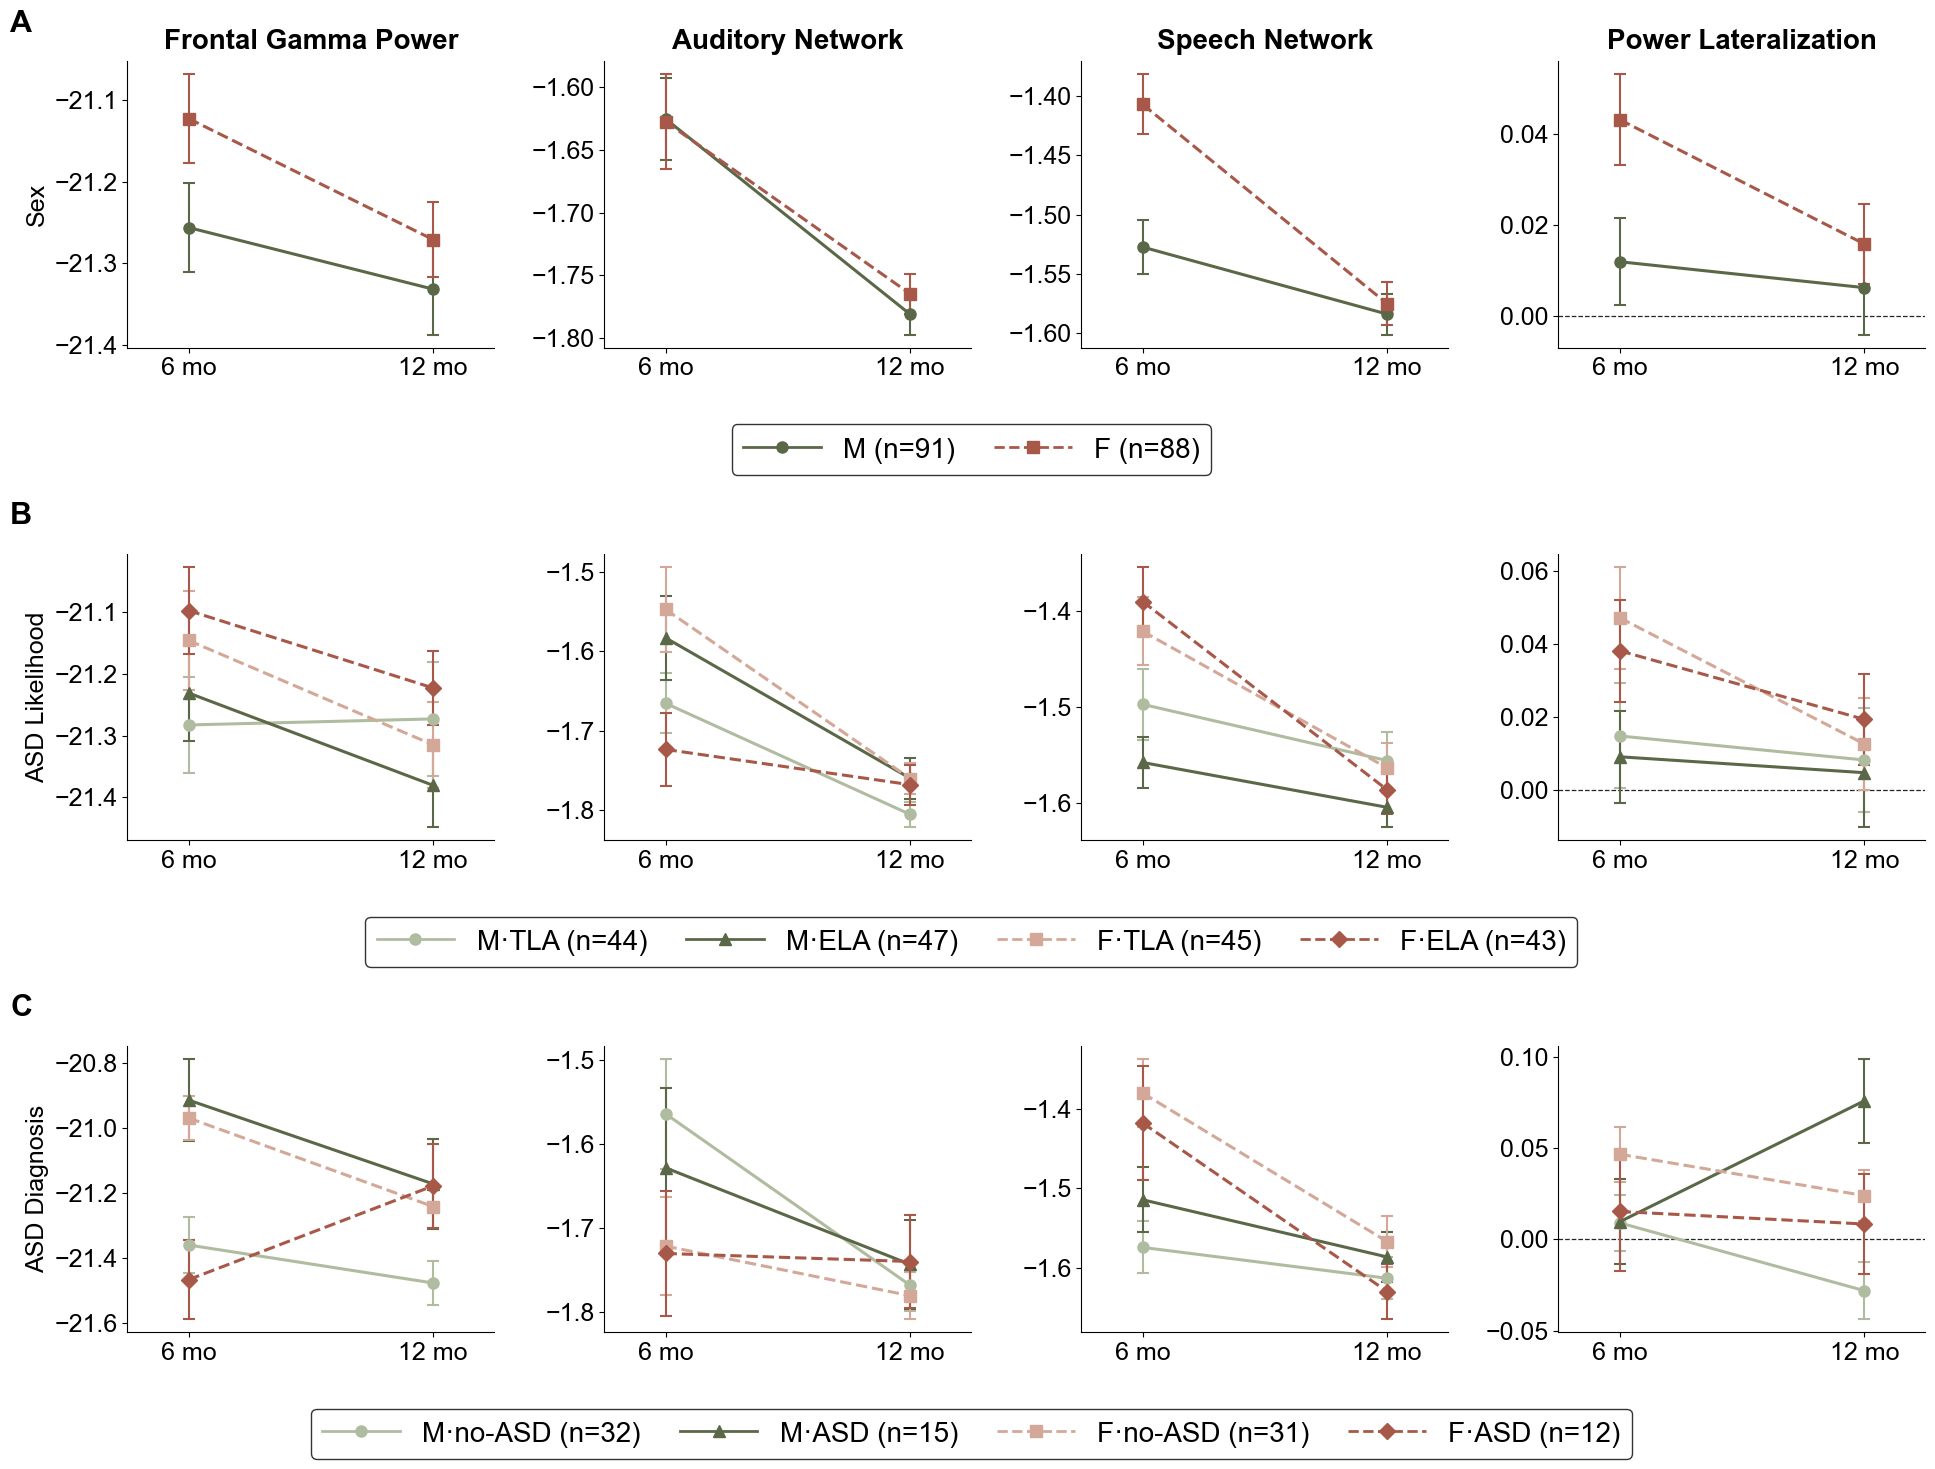

In [210]:
# ── Palettes — Muted Olive & Faded Brick ──────────────────────────────────────
#   M_DARK   #5A6848  Muted Olive   → M (row 1), M·ELA, M·asd
#   M_LIGHT  #B0BCA0  Pale Sage     → M·TLA, M·no-asd
#   F_DARK   #A85848  Faded Brick   → F (row 1), F·ELA, F·asd
#   F_LIGHT  #D4A898  Pale Terracotta → F·TLA, F·no-asd

M_DARK  = '#5A6848'
M_LIGHT = '#B0BCA0'
F_DARK  = '#A85848'
F_LIGHT = '#D4A898'

# Row 1 — Sex
sex_palette = {'M': M_DARK, 'F': F_DARK}
sex_ls      = {'M': '-',    'F': '--'}
sex_marker  = {'M': 'o',    'F': 's'}
sex_order   = ['M', 'F']

# Rows 2 & 3 — 4 groups
like_palette = {'M·TLA': M_LIGHT, 'M·ELA': M_DARK, 'F·TLA': F_LIGHT, 'F·ELA': F_DARK}
like_ls      = {'M·TLA': '-',  'M·ELA': '-',  'F·TLA': '--', 'F·ELA': '--'}
like_marker  = {'M·TLA': 'o',  'M·ELA': '^',  'F·TLA': 's',  'F·ELA': 'D'}
like_order   = ['M·TLA', 'M·ELA', 'F·TLA', 'F·ELA']

dx_palette  = {'M·no-ASD': M_LIGHT, 'M·ASD': M_DARK, 'F·no-ASD': F_LIGHT, 'F·ASD': F_DARK}
dx_ls       = {'M·no-ASD': '-',  'M·ASD': '-',  'F·no-ASD': '--', 'F·ASD': '--'}
dx_marker   = {'M·no-ASD': 'o',  'M·ASD': '^',  'F·no-ASD': 's',  'F·ASD': 'D'}
dx_order    = ['M·no-ASD', 'M·ASD', 'F·no-ASD', 'F·ASD']

# ── Metrics ───────────────────────────────────────────────────────────────────

metrics = {
    'Frontal Gamma Power':  ['Frontal Gamma Power 6mo',  'Frontal Gamma Power 12mo'],
    'Auditory Network':     ['Auditory Network 6mo',     'Auditory Network 12mo'],
    'Speech Network':       ['Speech Network 6mo',       'Speech Network 12mo'],
    'Power Lateralization': ['Power Lateralization 6mo', 'Power Lateralization 12mo'],
}
metric_names = list(metrics.keys())
x_pos     = [0, 1]
tp_labels = ['6 mo', '12 mo']

# ── rcParams ──────────────────────────────────────────────────────────────────

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica Neue', 'DejaVu Sans'],
    'font.size': 18, 'axes.titlesize': 20, 'axes.titleweight': 'bold',
    'axes.labelsize': 18, 'xtick.labelsize': 18, 'ytick.labelsize': 18,
    'legend.fontsize': 14, 'legend.title_fontsize': 14,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': False, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
})

# ── Pre-build group columns ───────────────────────────────────────────────────

plot_like = plotting_df.dropna(subset=['sex', 'group_type']).copy()
plot_like['sex_like'] = plot_like['sex'] + '·' + plot_like['group_type']
plot_like['sex_like'] = pd.Categorical(plot_like['sex_like'],
                                        categories=like_order, ordered=True)

plot_dx = plotting_df[plotting_df['group_type'] == 'ELA'].dropna(subset=['sex', 'outcome']).copy()
plot_dx['sex_dx'] = plot_dx['sex'] + '·' + plot_dx['outcome'].str.replace('asd', 'ASD', case=False)
plot_dx['sex_dx'] = pd.Categorical(plot_dx['sex_dx'],
                                    categories=dx_order, ordered=True)

# ── Pre-compute sample sizes ──────────────────────────────────────────────────

n_sex  = {g: int(plotting_df[plotting_df['sex'] == g].shape[0])
           for g in sex_order}
n_like = {g: int(plot_like[plot_like['sex_like'] == g].shape[0])
           for g in like_order}
n_dx   = {g: int(plot_dx[plot_dx['sex_dx'] == g].shape[0])
           for g in dx_order}

def n_label(n_dict):
    """Return a compact 'n=' annotation string for a group dict."""
    return '  '.join(f'{k}: n={v}' for k, v in n_dict.items())

# Accumulators for per-row legend handles
row_handles = [[], [], []]

# ── Figure ────────────────────────────────────────────────────────────────────

fig, axs = plt.subplots(3, 4, figsize=(5.8 * 4, 5.5 * 3),
                         gridspec_kw={'hspace': 0.72, 'wspace': 0.30})

for col_idx, metric in enumerate(metric_names):
    cols   = metrics[metric]
    is_lat = (metric == 'Power Lateralization')

    def zero_line(ax):
        if is_lat:
            ax.axhline(0, color="#252525", linewidth=0.9, linestyle='--', zorder=-1)

    # ── ROW 0 — Sex ───────────────────────────────────────────────────────────
    ax = axs[0, col_idx]
    for grp in sex_order:
        sub   = plotting_df[plotting_df['sex'] == grp]
        means = [sub[c].mean() for c in cols]
        sems  = [sub[c].sem()  for c in cols]
        ax.errorbar(x_pos, means, yerr=sems,
                    color=sex_palette[grp], linestyle=sex_ls[grp],
                    marker=sex_marker[grp], markersize=8, linewidth=2.2,
                    capsize=4, capthick=1.5, elinewidth=1.5)
        if col_idx == 0:
            row_handles[0].append(
                Line2D([0],[0], color=sex_palette[grp], linestyle=sex_ls[grp],
                       marker=sex_marker[grp], markersize=8, linewidth=2,
                       label=f'{grp} (n={n_sex[grp]})'))
    zero_line(ax)
    ax.set_xticks(x_pos); ax.set_xticklabels(tp_labels)
    ax.set_xlim(-0.25, 1.25)
    ax.set_title(metric, pad=9)
    ax.set_ylabel('Sex' if col_idx == 0 else '')

    # ── ROW 1 — ASD Likelihood ────────────────────────────────────────────────
    ax = axs[1, col_idx]
    for grp in like_order:
        sub   = plot_like[plot_like['sex_like'] == grp]
        means = [sub[c].mean() for c in cols]
        sems  = [sub[c].sem()  for c in cols]
        ax.errorbar(x_pos, means, yerr=sems,
                    color=like_palette[grp], linestyle=like_ls[grp],
                    marker=like_marker[grp], markersize=8, linewidth=2.2,
                    capsize=4, capthick=1.5, elinewidth=1.5)
        if col_idx == 0:
            row_handles[1].append(
                Line2D([0],[0], color=like_palette[grp], linestyle=like_ls[grp],
                       marker=like_marker[grp], markersize=8, linewidth=2,
                       label=f'{grp} (n={n_like[grp]})'))
    zero_line(ax)
    ax.set_xticks(x_pos); ax.set_xticklabels(tp_labels)
    ax.set_xlim(-0.25, 1.25)
    ax.set_ylabel('ASD Likelihood' if col_idx == 0 else '')

    # ── ROW 2 — ASD Diagnosis (ELA only) ──────────────────────────────────────
    ax = axs[2, col_idx]
    for grp in dx_order:
        sub   = plot_dx[plot_dx['sex_dx'] == grp]
        means = [sub[c].mean() for c in cols]
        sems  = [sub[c].sem()  for c in cols]
        ax.errorbar(x_pos, means, yerr=sems,
                    color=dx_palette[grp], linestyle=dx_ls[grp],
                    marker=dx_marker[grp], markersize=8, linewidth=2.2,
                    capsize=4, capthick=1.5, elinewidth=1.5)
        if col_idx == 0:
            row_handles[2].append(
                Line2D([0],[0], color=dx_palette[grp], linestyle=dx_ls[grp],
                       marker=dx_marker[grp], markersize=8, linewidth=2,
                       label=f'{grp} (n={n_dx[grp]})'))
    zero_line(ax)
    ax.set_xticks(x_pos); ax.set_xticklabels(tp_labels)
    ax.set_xlim(-0.25, 1.25)
    ax.set_ylabel('ASD Diagnosis' if col_idx == 0 else '')

# ── Panel letters ────────────────────────────────────────────────────────────

for row_idx, letter in enumerate(['A', 'B', 'C']):
    axs[row_idx, 0].text(
        -0.32, 1.18, letter,
        transform=axs[row_idx, 0].transAxes,
        fontsize=22, fontweight='bold', va='top', ha='left',
        fontfamily='sans-serif',
    )

# ── Horizontal legends — one per row, centred below ──────────────────────────

for row_idx, handles in enumerate(row_handles):
    axs[row_idx, 1].legend(
        handles=handles, title=None,
        loc='upper center',
        bbox_to_anchor=(1.0, -0.22),
        ncol=len(handles),
        frameon=True, facecolor='white', edgecolor='black',
        fontsize=20,
        handlelength=2.8, handleheight=1.0,
        columnspacing=1.4,
    )

# ── Save ──────────────────────────────────────────────────────────────────────

os.makedirs('../../figures/main/', exist_ok=True)
plt.savefig('../../figures/main/Sex_differences_likelihood_diagnosis.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

### **Supplementary S1** EEG Feature Distribution by sex

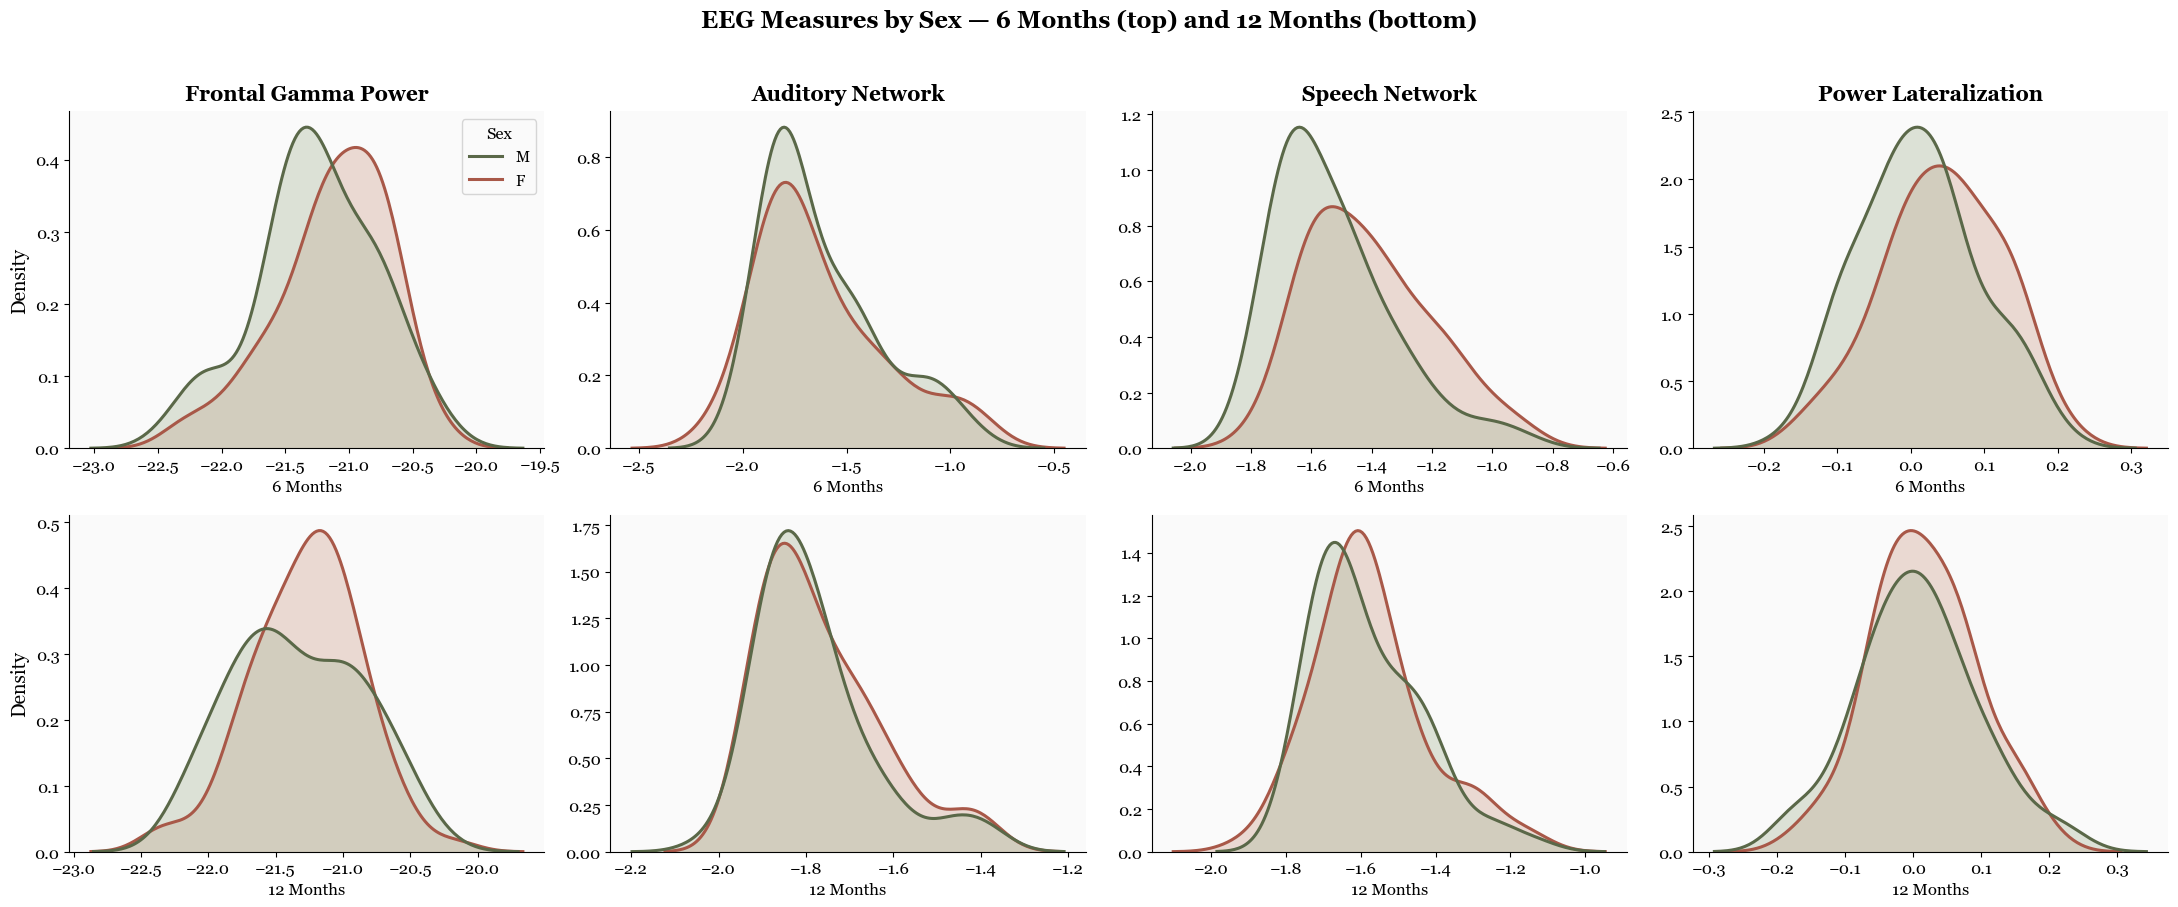

In [218]:
# EEG distributions (6mo and 12mo): Male vs Female
# Two-pass KDE: pale fill + darker outline — muted olive / faded brick palette
plt.rcParams.update({
    'font.family':           'serif',
    'font.serif':            ['Georgia', 'Times New Roman', 'DejaVu Serif'],
    'font.size':             14,
    'axes.titlesize':        15,
    'axes.titleweight':      'bold',
    'axes.labelsize':        13,
    'xtick.labelsize':       12,
    'ytick.labelsize':       12,
    'legend.fontsize':       12,
    'legend.title_fontsize': 12,
    'axes.spines.top':       False,
    'axes.spines.right':     False,
    'axes.grid':             False,
    'figure.facecolor':      'white',
    'axes.facecolor':        '#fafafa',
})

# Pale fill colours — matches M_LIGHT / F_LIGHT from main palette
sex_palette      = {'M': M_LIGHT, 'F': F_LIGHT}   # '#B0BCA0', '#D4A898'
# Darker outline colours — matches M_DARK / F_DARK from main palette
sex_line_palette = {'M': M_DARK,  'F': F_DARK}    # '#5A6848', '#A85848'

sex_order = ['M', 'F']

# 4 focal metrics: (display name, 6mo col, 12mo col)
focal_metrics_hist = [
    ('Frontal Gamma Power', 'Frontal Gamma Power 6mo', 'Frontal Gamma Power 12mo'),
    ('Auditory Network',    'Auditory Network 6mo',    'Auditory Network 12mo'),
    ('Speech Network',      'Speech Network 6mo',      'Speech Network 12mo'),
    ('Power Lateralization','Power Lateralization 6mo', 'Power Lateralization 12mo'),
]

fig, axs = plt.subplots(2, 4, figsize=(5.5 * 4, 4.5 * 2))

for col_idx, (metric_name, col_6, col_12) in enumerate(focal_metrics_hist):
    for row_idx, (col, tp_label) in enumerate([(col_6, '6 Months'), (col_12, '12 Months')]):
        ax = axs[row_idx, col_idx]
        if col not in plotting_df.columns:
            ax.set_visible(False)
            continue
        data = plotting_df.dropna(subset=[col, 'sex'])

        # Pass 1: pale filled area, no visible outline
        sns.kdeplot(
            data=data, x=col, hue='sex',
            hue_order=sex_order,
            palette=sex_palette,
            fill=True, alpha=0.40, linewidth=0,
            ax=ax,
        )
        # Pass 2: darker outline line only (no fill)
        sns.kdeplot(
            data=data, x=col, hue='sex',
            hue_order=sex_order,
            palette=sex_line_palette,
            fill=False, linewidth=2.2,
            ax=ax,
        )

        if row_idx == 0:
            ax.set_title(metric_name, pad=8)
        ax.set_xlabel(tp_label, fontsize=12)
        ax.set_ylabel('Density' if col_idx == 0 else '')

        # Keep only the top-left legend; remove duplicates from pass 2
        legends = ax.get_legend()
        if legends:
            if row_idx == 0 and col_idx == 0:
                legends.set_title('Sex')
                legends.get_title().set_fontsize(12)
                for txt in legends.get_texts():
                    txt.set_fontsize(11)
            else:
                legends.remove()

fig.suptitle('EEG Measures by Sex — 6 Months (top) and 12 Months (bottom)',
             fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout()

os.makedirs('../../figures/supplementary/', exist_ok=True)
plt.savefig('../../figures/supplementary/S1_eeg_sex_diff_histograms.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


### **Supplementary S2** EEG diatributions for Sex x Likelihood

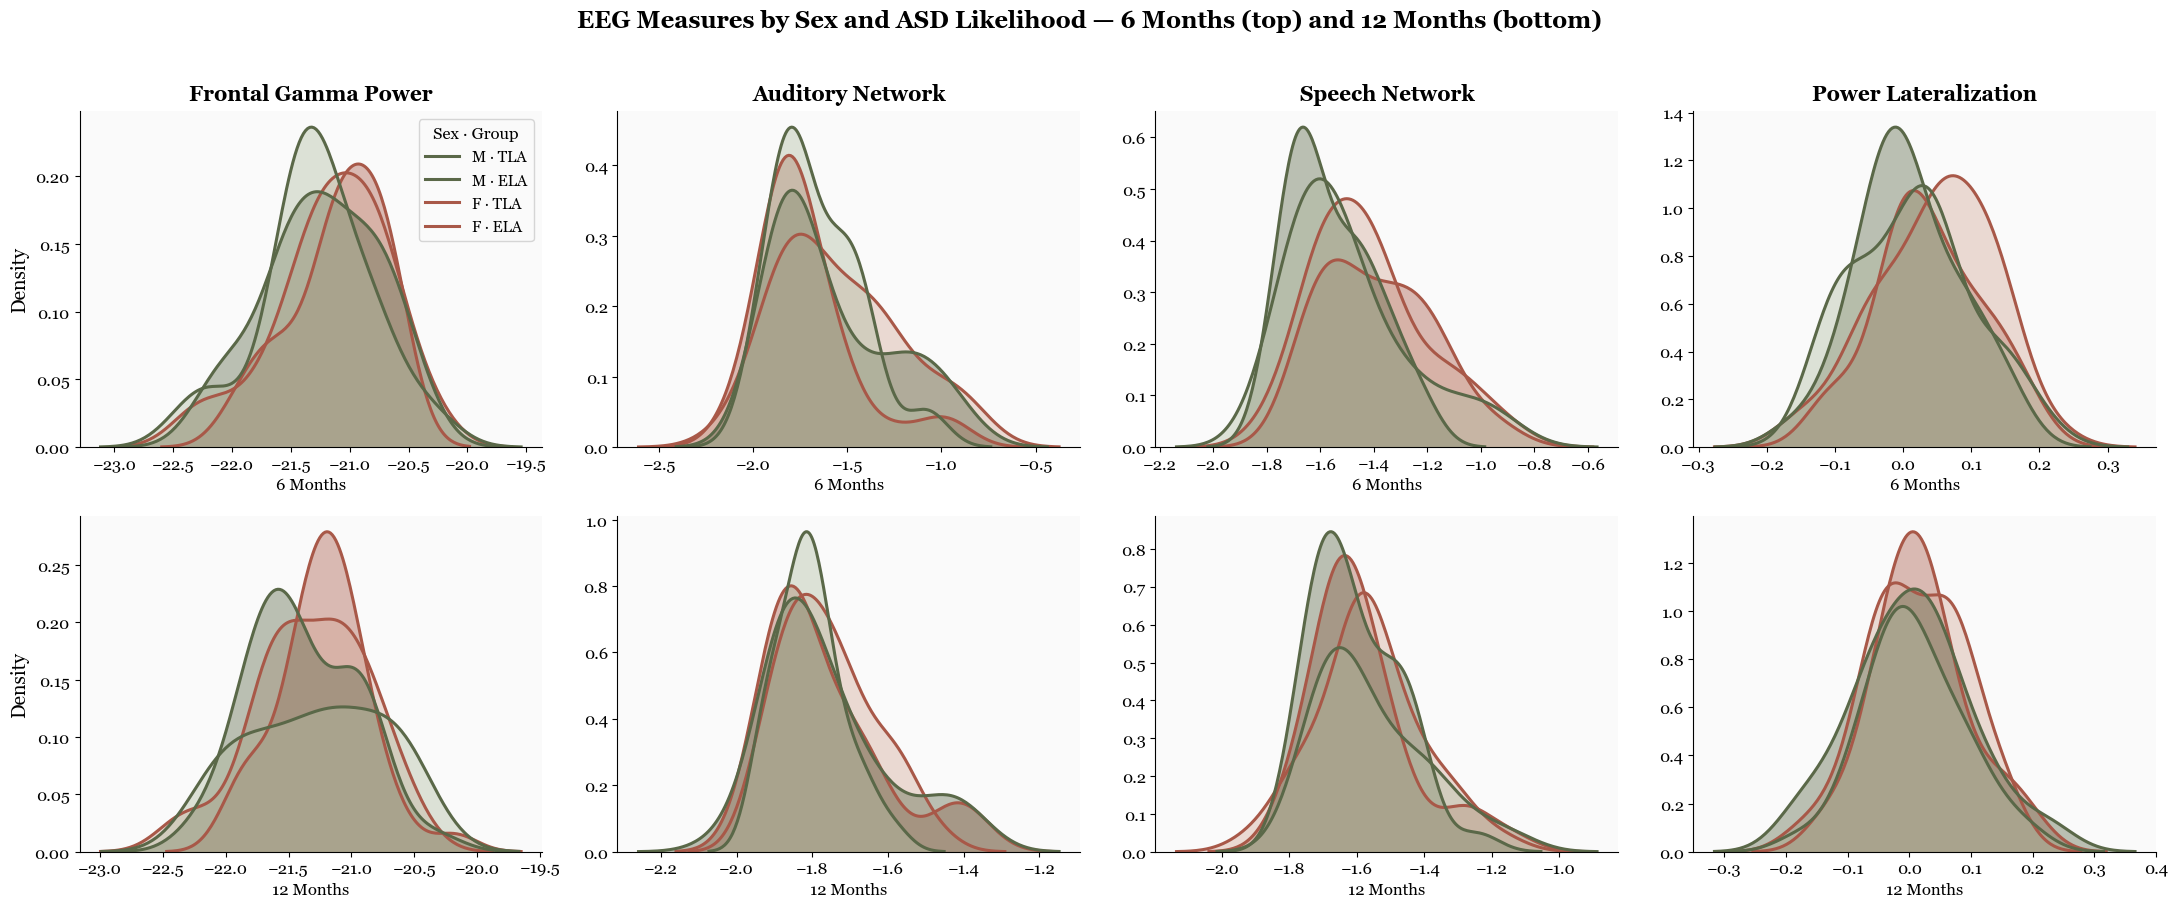

In [219]:


# Fill colours — matches M_LIGHT/M_DARK/F_LIGHT/F_DARK from main palette
group_palette = {
    'M · TLA': M_LIGHT,   # '#B0BCA0'  Pale Sage
    'M · ELA': M_DARK,    # '#5A6848'  Muted Olive
    'F · TLA': F_LIGHT,   # '#D4A898'  Pale Terracotta
    'F · ELA': F_DARK,    # '#A85848'  Faded Brick
}
# Outline line colours (dark anchor for both TLA and ELA within each sex)
group_line_palette = {
    'M · TLA': M_DARK,    # '#5A6848'
    'M · ELA': M_DARK,    # '#5A6848'
    'F · TLA': F_DARK,    # '#A85848'
    'F · ELA': F_DARK,    # '#A85848'
}

group_order = ['M · TLA', 'M · ELA', 'F · TLA', 'F · ELA']

plot2 = plotting_df.dropna(subset=['sex', 'group_type']).copy()
plot2['sex_group'] = plot2['sex'] + ' · ' + plot2['group_type']
plot2['sex_group'] = pd.Categorical(plot2['sex_group'], categories=group_order, ordered=True)

fig2, axs2 = plt.subplots(2, 4, figsize=(5.5 * 4, 4.5 * 2))

for col_idx, (metric_name, col_6, col_12) in enumerate(focal_metrics_hist):
    for row_idx, (col, tp_label) in enumerate([(col_6, '6 Months'), (col_12, '12 Months')]):
        ax = axs2[row_idx, col_idx]
        sub = plot2.dropna(subset=[col]) if col in plot2.columns else None
        if sub is None or col not in plot2.columns:
            ax.set_visible(False)
            continue

        # Pass 1: pale filled area, no visible outline
        sns.kdeplot(
            data=sub, x=col, hue='sex_group',
            hue_order=group_order,
            palette=group_palette,
            fill=True, alpha=0.40, linewidth=0,
            ax=ax,
        )
        # Pass 2: darker outline line only (no fill)
        sns.kdeplot(
            data=sub, x=col, hue='sex_group',
            hue_order=group_order,
            palette=group_line_palette,
            fill=False, linewidth=2.2,
            ax=ax,
        )

        if row_idx == 0:
            ax.set_title(metric_name, pad=8)
        ax.set_xlabel(tp_label, fontsize=12)
        ax.set_ylabel('Density' if col_idx == 0 else '')

        # Keep only one legend (top-left panel); remove duplicates from pass 2
        legends = ax.get_legend()
        if legends:
            if row_idx == 0 and col_idx == 0:
                legends.set_title('Sex · Group')
                legends.get_title().set_fontsize(12)
                for txt in legends.get_texts():
                    txt.set_fontsize(11)
            else:
                legends.remove()

fig2.suptitle(
    'EEG Measures by Sex and ASD Likelihood — 6 Months (top) and 12 Months (bottom)',
    fontsize=17, fontweight='bold', y=1.01
)
plt.tight_layout()

os.makedirs('../../figures/supplementary/', exist_ok=True)
plt.savefig('../../figures/supplementary/S2_eeg_focal_sex_x_group_kdeplots.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


### **Supplementary S3** EEG diatributions for ASD vs no ASD, trajectoreis 6-18mo

C:\Users\gabot\AppData\Local\Temp\ipykernel_35956\1317083840.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\gabot\AppData\Local\Temp\ipykernel_35956\1317083840.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
C:\Users\gabot\AppData\Local\Temp\ipykernel_35956\1317083840.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\gabot\AppData\Local\Temp\ipykernel_35956\1317083840.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable t

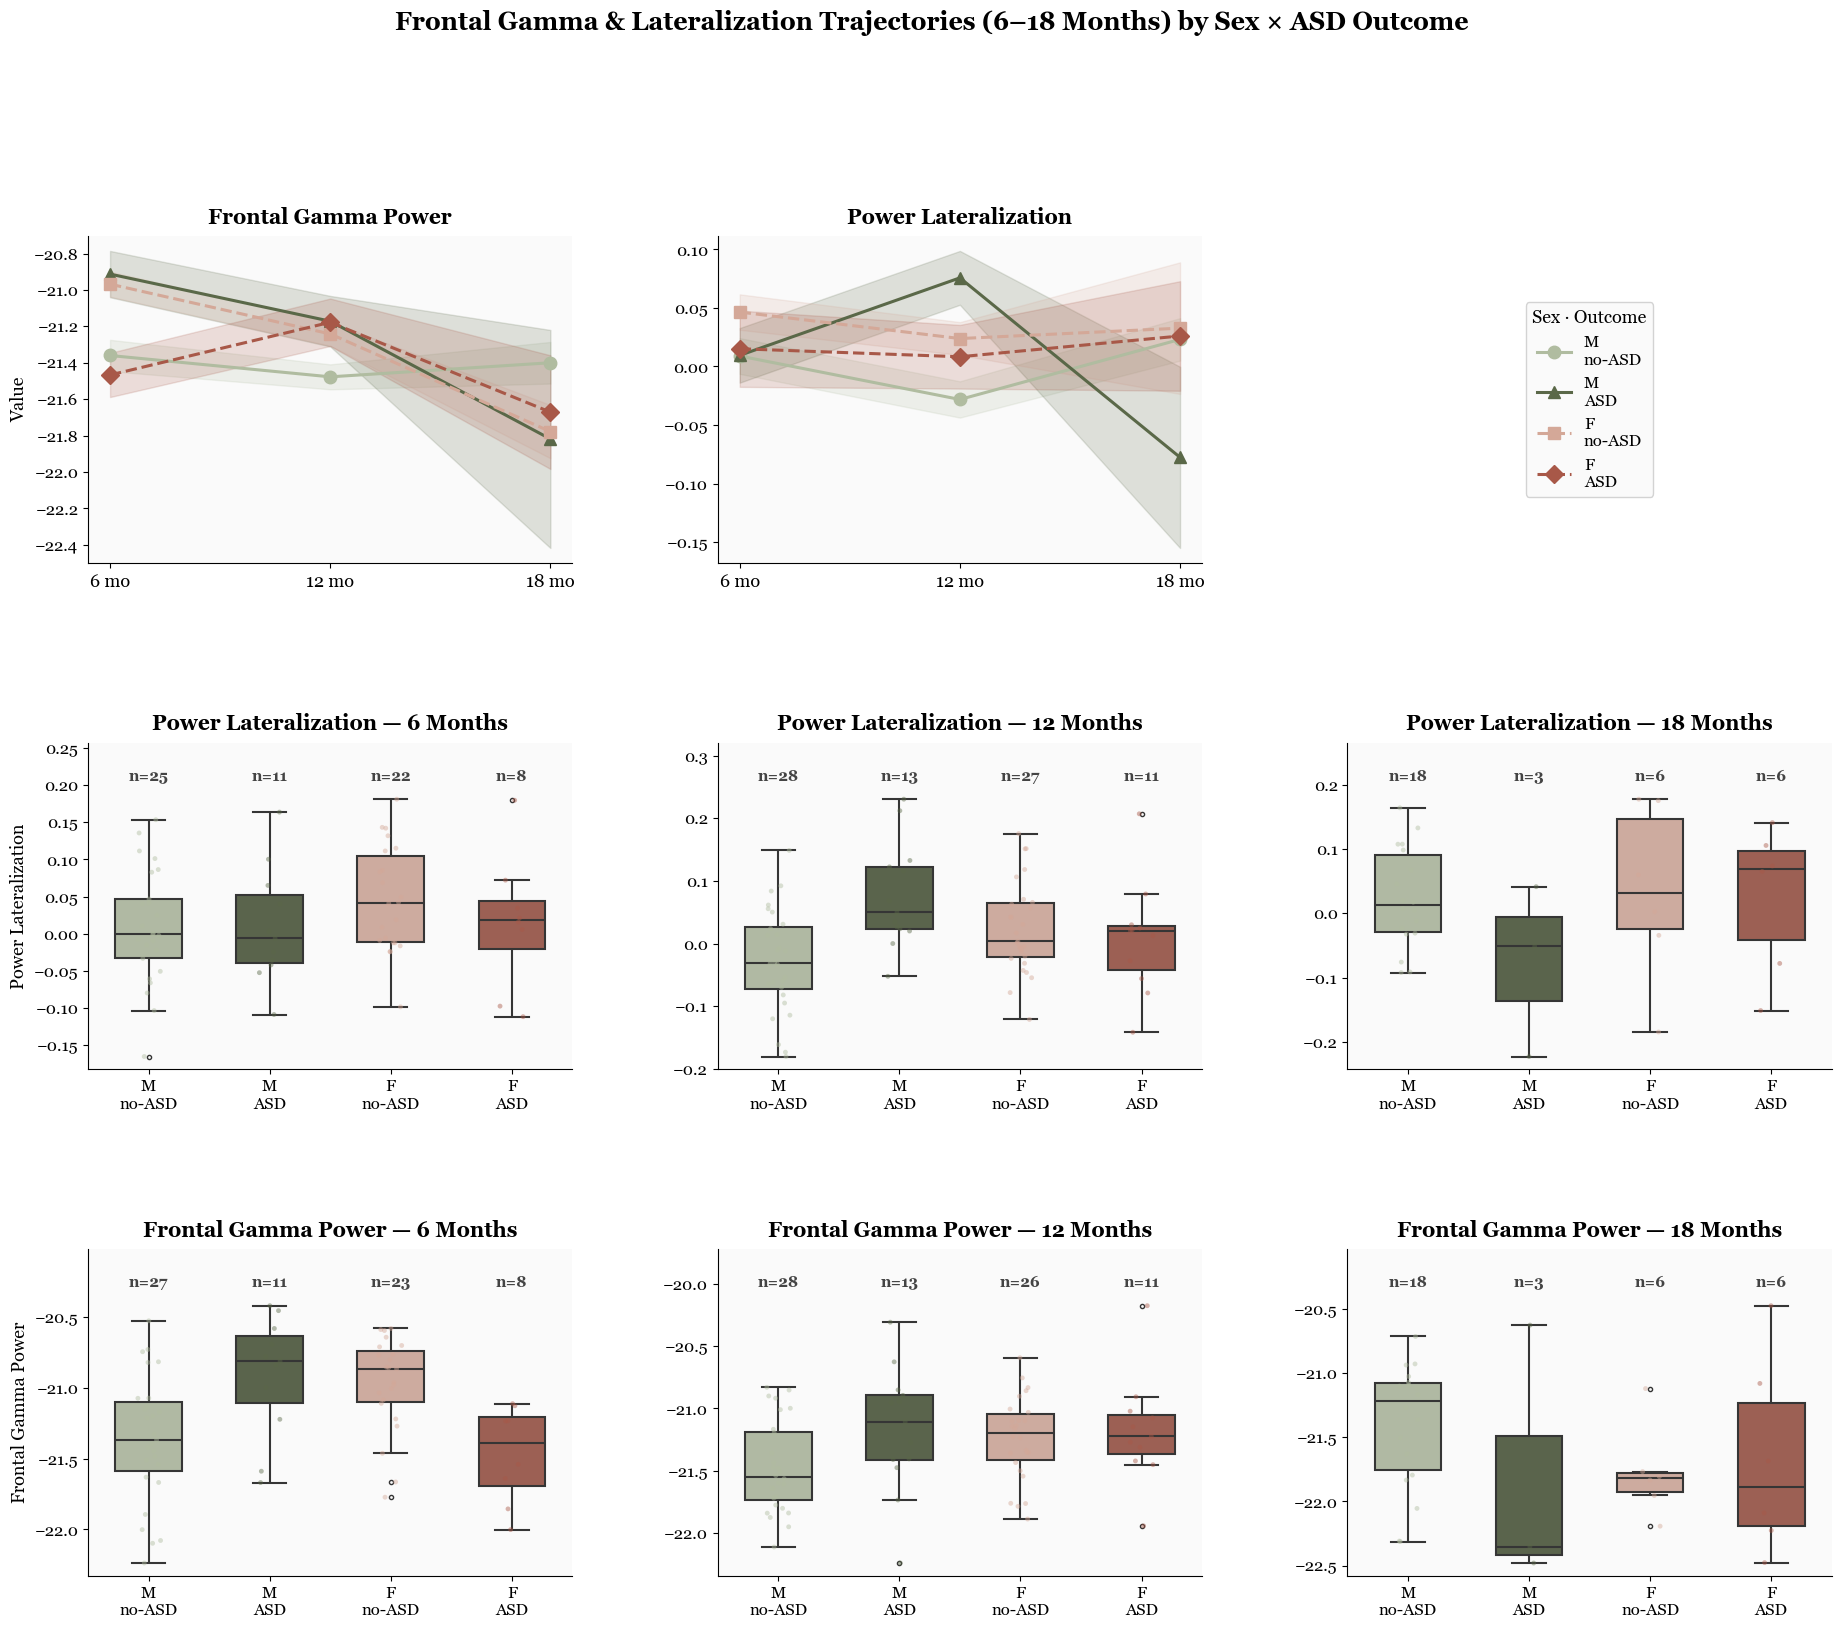

In [ ]:
# EEG trajectories (6 → 12 → 18 months): Frontal Gamma Power and Power Lateralization


outcome_order  = ['M · no-ASD', 'M · ASD', 'F · no-ASD', 'F · ASD']
outcome_labels = ['M\nno-ASD',   'M\nASD',   'F\nno-ASD',   'F\nASD']

outcome_palette = {
    'M · no-ASD': M_LIGHT,
    'M · ASD':    M_DARK,
    'F · no-ASD': F_LIGHT,
    'F · ASD':    F_DARK,
}
line_styles = {
    'M · no-ASD': '-',
    'M · ASD':    '-',
    'F · no-ASD': '--',
    'F · ASD':    '--',
}
markers_map = {
    'M · no-ASD': 'o',
    'M · ASD':    '^',
    'F · no-ASD': 's',
    'F · ASD':    'D',
}

# Build plot3: ELA participants with sex × ASD outcome group column
plot3 = plotting_df[plotting_df['group_type'] == 'ELA'].dropna(subset=['sex', 'outcome']).copy()
plot3['sex_outcome'] = (
    plot3['sex'] + ' · ' +
    plot3['outcome'].str.replace('asd', 'ASD', case=False)
                    .str.replace('no-asd', 'no-ASD', case=False)
                    .str.replace('No-ASD', 'no-ASD')
)
plot3['sex_outcome'] = pd.Categorical(plot3['sex_outcome'],
                                       categories=outcome_order, ordered=True)

# ── Focal metrics with 3 timepoints ─────────────────────────────────────────
focal_traj_18 = {
    'Frontal Gamma Power': [
        'Frontal Gamma Power 6mo',
        'Frontal Gamma Power 12mo',
        'Frontal Gamma Power 18mo',
    ],
    'Power Lateralization': [
        'Power Lateralization 6mo',
        'Power Lateralization 12mo',
        'Power Lateralization 18mo',
    ],
}

fig4, axs4 = plt.subplots(3, 3, figsize=(7.5 * 3, 5.8 * 3),
                           gridspec_kw={'height_ratios': [1, 1, 1],
                                        'hspace': 0.55, 'wspace': 0.30})

# ── Row 0: trajectory line plots (3 timepoints) ───────────────────────────
for ax_idx, (measure_name, cols) in enumerate(focal_traj_18.items()):
    ax = axs4[0, ax_idx]
    x_pos = list(range(len(cols)))

    for group in outcome_order:
        grp   = plot3[plot3['sex_outcome'] == group]
        means = [grp[c].mean() for c in cols]
        sems  = [grp[c].sem()  for c in cols]
        color = outcome_palette[group]
        ax.plot(x_pos, means,
                color=color, linestyle=line_styles[group],
                marker=markers_map[group], markersize=9,
                linewidth=2.2, label=group.replace(' · ', '\n'))
        ax.fill_between(x_pos,
                        [m - s for m, s in zip(means, sems)],
                        [m + s for m, s in zip(means, sems)],
                        color=color, alpha=0.18)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(['6 mo', '12 mo', '18 mo'], fontsize=13)
    ax.set_title(measure_name, fontsize=15, fontweight='bold', pad=9)
    ax.set_ylabel('Value' if ax_idx == 0 else '', fontsize=13)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Legend in the third top panel (no plot)
handles_leg, labels_leg = axs4[0, 0].get_legend_handles_labels()
axs4[0, 2].legend(handles_leg, labels_leg,
                  title='Sex · Outcome', fontsize=12, title_fontsize=13,
                  framealpha=0.85, loc='center')
axs4[0, 2].axis('off')

# ── Row 1: Power Lateralization boxplots ──────────────────────────────────
for tp_idx, (tp_col, tp_label) in enumerate([
    ('Power Lateralization 6mo',  '6 Months'),
    ('Power Lateralization 12mo', '12 Months'),
    ('Power Lateralization 18mo', '18 Months'),
]):
    ax = axs4[1, tp_idx]
    valid = plot3.dropna(subset=[tp_col])

    sns.boxplot(
        data=valid, x='sex_outcome', y=tp_col,
        order=outcome_order, palette=outcome_palette,
        width=0.55, linewidth=1.5, fliersize=3, ax=ax,
    )
    sns.stripplot(
        data=valid, x='sex_outcome', y=tp_col,
        order=outcome_order, palette=outcome_palette,
        size=3.5, alpha=0.45, jitter=True, ax=ax,
    )

    y_max   = valid[tp_col].max()
    y_range = valid[tp_col].max() - valid[tp_col].min()
    for g_idx, group in enumerate(outcome_order):
        n = (valid['sex_outcome'] == group).sum()
        ax.text(g_idx, y_max + y_range * 0.06, f'n={n}',
                ha='center', va='bottom', fontsize=11,
                fontweight='bold', color='#444444')
    ax.set_ylim(top=y_max + y_range * 0.22)
    ax.set_xticks(range(len(outcome_order)))
    ax.set_xticklabels(outcome_labels, fontsize=12)
    ax.set_xlabel('')
    ax.set_title(f'Power Lateralization — {tp_label}',
                 fontsize=15, fontweight='bold', pad=9)
    ax.set_ylabel('Power Lateralization' if tp_idx == 0 else '', fontsize=13)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── Row 2: Frontal Gamma Power boxplots ───────────────────────────────────
for tp_idx, (tp_col, tp_label) in enumerate([
    ('Frontal Gamma Power 6mo',  '6 Months'),
    ('Frontal Gamma Power 12mo', '12 Months'),
    ('Frontal Gamma Power 18mo', '18 Months'),
]):
    ax = axs4[2, tp_idx]
    valid = plot3.dropna(subset=[tp_col])

    sns.boxplot(
        data=valid, x='sex_outcome', y=tp_col,
        order=outcome_order, palette=outcome_palette,
        width=0.55, linewidth=1.5, fliersize=3, ax=ax,
    )
    sns.stripplot(
        data=valid, x='sex_outcome', y=tp_col,
        order=outcome_order, palette=outcome_palette,
        size=3.5, alpha=0.45, jitter=True, ax=ax,
    )

    y_max   = valid[tp_col].max()
    y_range = valid[tp_col].max() - valid[tp_col].min()
    for g_idx, group in enumerate(outcome_order):
        n = (valid['sex_outcome'] == group).sum()
        ax.text(g_idx, y_max + y_range * 0.06, f'n={n}',
                ha='center', va='bottom', fontsize=11,
                fontweight='bold', color='#444444')
    ax.set_ylim(top=y_max + y_range * 0.22)
    ax.set_xticks(range(len(outcome_order)))
    ax.set_xticklabels(outcome_labels, fontsize=12)
    ax.set_xlabel('')
    ax.set_title(f'Frontal Gamma Power — {tp_label}',
                 fontsize=15, fontweight='bold', pad=9)
    ax.set_ylabel('Frontal Gamma Power' if tp_idx == 0 else '', fontsize=13)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig4.suptitle(
    'Frontal Gamma & Lateralization Trajectories (6–18 Months) by Sex × ASD Outcome',
    fontsize=18, fontweight='bold', y=1.01
)
plt.tight_layout()

os.makedirs('../../figures/supplementary/', exist_ok=True)
plt.savefig('../../figures/supplementary/S3_eeg_focal_trajectories_18mo_sex_asd_outcome.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


# **Main 2** Language growth curves

In [ ]:
## Create wide long format for langauge measures

lang_wide=plotting_df.copy()
cleaned_expres_vars = [var for var in cleaned_language_vars if "expressive" in var.lower() ]
cleaned_receptive_vars = [var for var in cleaned_language_vars if "receptive" in var.lower() ]
expressive_df= lang_wide[["HC Class"] + ["LPA Class"] + ["sex"] + ["outcome"] + ["subject"] + cleaned_expres_vars]
receptive_df= lang_wide[["HC Class"] + ["LPA Class"] + ["sex"] + ["outcome"] +["subject"]+ cleaned_receptive_vars]



# Rename the timepoints
expressive_df = expressive_df.melt(id_vars=["HC Class", "LPA Class","subject",'sex', 'outcome'], var_name="Age", value_name="score")
expressive_df["Age"] = expressive_df["Age"].str.extract("(\d+)").astype(int)
expressive_df["Measure"] = "Expressive"

# Rename the timepoints
receptive_df = receptive_df.melt(id_vars=["HC Class", "LPA Class","subject",'sex','outcome'], var_name="Age", value_name="score")
receptive_df["Age"] = receptive_df["Age"].str.extract("(\d+)").astype(int)
receptive_df["Measure"] = "Receptive"
ages = [6, 12, 18, 24, 36]


### Expressive language scores HC Classes

C:\Users\gabot\AppData\Local\Temp\ipykernel_35956\2426445846.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


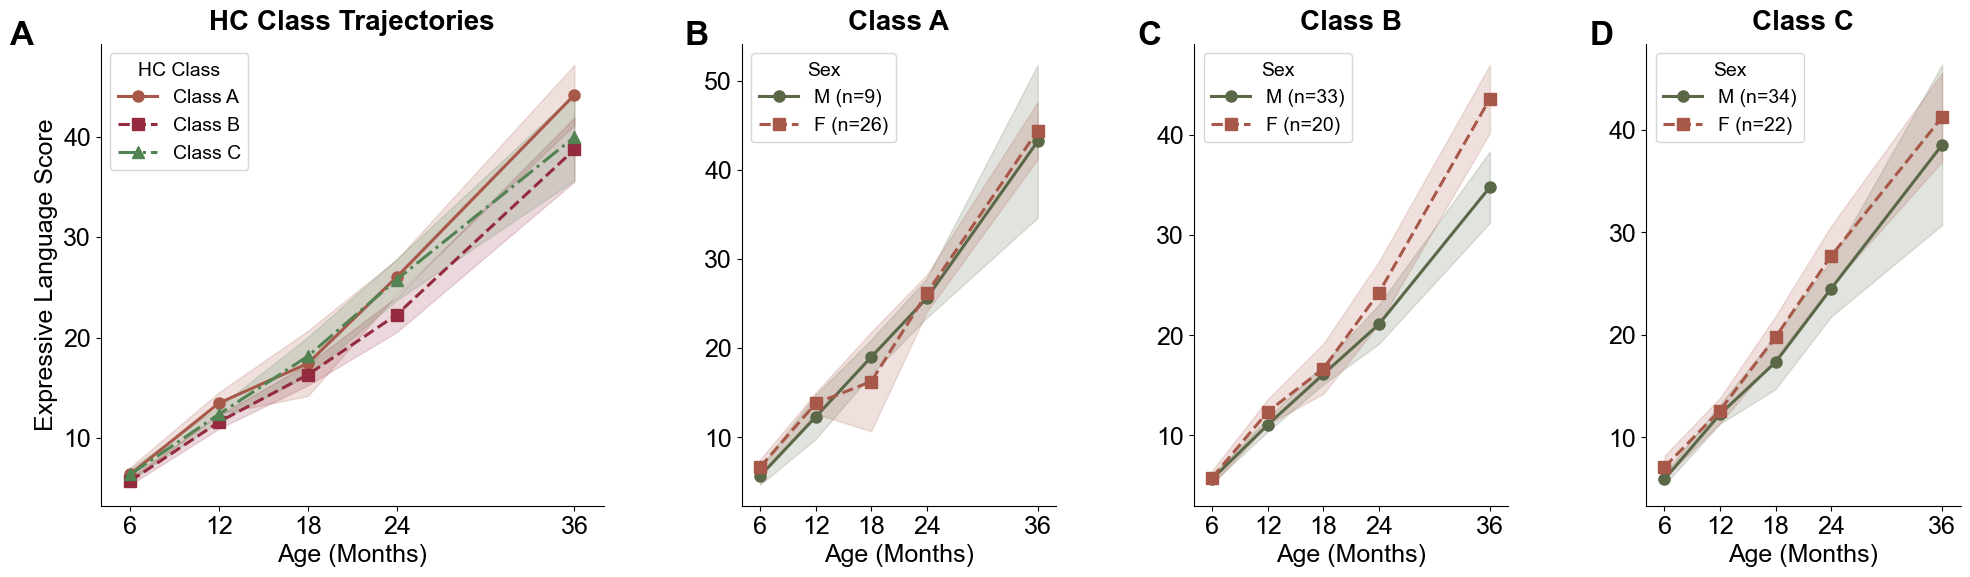

In [287]:
# ── Expressive Language: HC Class trajectories + sex within each class ────────


plt.rcParams.update({
    'font.family':           'sans-serif',
    'font.sans-serif':       ['Arial', 'Helvetica Neue', 'DejaVu Sans'],
    'font.size':             18,
    'axes.titlesize':        20,
    'axes.titleweight':      'bold',
    'axes.labelsize':        18,
    'xtick.labelsize':       18,
    'ytick.labelsize':       18,
    'legend.fontsize':       14,
    'legend.title_fontsize': 14,
    'axes.spines.top':       False,
    'axes.spines.right':     False,
    'axes.grid':             False,
    'figure.facecolor':      'white',
    'axes.facecolor':        'white',
})

# ── Palettes ──────────────────────────────────────────────────────────────────
# HC class colours — warm neutrals distinct from the M/F sex palette
hc_class_palette = {
    'a': "#A85848",   # muted amber
    'c': "#528352",   # muted sage green
    'b': "#942A3E",   # muted maroon

}
hc_class_ls     = {'a': '-',  'b': '--', 'c': '-.'}
hc_class_marker = {'a': 'o',  'b': 's',  'c': '^'}
hc_class_order  = sorted(expressive_df['HC Class'].dropna().unique())

# Sex colours — reuse M_DARK / F_DARK from main palette
sex_col_palette = {'M': M_DARK,  'F': F_DARK}
sex_col_ls      = {'M': '-',     'F': '--'}
sex_col_marker  = {'M': 'o',     'F': 's'}

# ── Figure — 1 × 4 with Panel A ~1.6× wider than B/C/D ──────────────────────
fig_lang, axs_lang = plt.subplots(
    1, 4,
    figsize=(6.0 * 4, 6.0),
    gridspec_kw={'width_ratios': [1.6, 1, 1, 1],
                 'wspace': 0.38},
)

panel_letters = ['A', 'B', 'C', 'D']

# ── Panel A: HC class overview (both sexes pooled) ────────────────────────────
ax = axs_lang[0]
for cls in hc_class_order:
    sub = expressive_df[expressive_df['HC Class'] == cls]
    grouped = sub.groupby('Age')['score'].agg(['mean', 'sem']).reset_index()
    grouped['ci_lo'] = grouped['mean'] - 1.96 * grouped['sem']
    grouped['ci_hi'] = grouped['mean'] + 1.96 * grouped['sem']
    ax.plot(grouped['Age'], grouped['mean'],
            color=hc_class_palette[cls], linestyle=hc_class_ls[cls],
            marker=hc_class_marker[cls], markersize=8, linewidth=2.2,
            label=f'Class {cls.upper()}')
    ax.fill_between(grouped['Age'], grouped['ci_lo'], grouped['ci_hi'],
                    color=hc_class_palette[cls], alpha=0.18)

ax.set_title('HC Class Trajectories', pad=10)
ax.set_xlabel('Age (Months)')
ax.set_ylabel('Expressive Language Score')
ax.set_xticks(ages)
ax.set_xlim(min(ages) - 2, max(ages) + 2)
ax.legend(title='HC Class', frameon=True, facecolor='white', edgecolor='#cccccc')

# Panel A letter
ax.text(-0.18, 1.05, 'A',
        transform=ax.transAxes,
        fontsize=24, fontweight='bold', va='top', ha='left')

# ── Panels B–D: M vs F within each HC class ───────────────────────────────────
for panel_idx, cls in enumerate(hc_class_order):
    ax = axs_lang[panel_idx + 1]
    sub_cls = expressive_df[expressive_df['HC Class'] == cls].dropna(subset=['sex'])

    for sex in ['M', 'F']:
        sub = sub_cls[sub_cls['sex'] == sex]
        if sub.empty:
            continue
        grouped = sub.groupby('Age')['score'].agg(['mean', 'sem']).reset_index()
        grouped['ci_lo'] = grouped['mean'] - 1.96 * grouped['sem']
        grouped['ci_hi'] = grouped['mean'] + 1.96 * grouped['sem']
        n_sub = sub['subject'].nunique() if 'subject' in sub.columns else len(sub)
        ax.plot(grouped['Age'], grouped['mean'],
                color=sex_col_palette[sex], linestyle=sex_col_ls[sex],
                marker=sex_col_marker[sex], markersize=8, linewidth=2.2,
                label=f'{sex} (n={n_sub})')
        ax.fill_between(grouped['Age'], grouped['ci_lo'], grouped['ci_hi'],
                        color=sex_col_palette[sex], alpha=0.18)

    ax.set_title(f'Class {cls.upper()}', pad=10)
    ax.set_xlabel('Age (Months)')
    ax.set_ylabel('')
    ax.set_xticks(ages)
    ax.set_xlim(min(ages) - 2, max(ages) + 2)
    ax.legend(title='Sex', frameon=True, facecolor='white', edgecolor='#cccccc')

    # Panel letters B, C, D
    ax.text(-0.18, 1.05, panel_letters[panel_idx + 1],
            transform=ax.transAxes,
            fontsize=24, fontweight='bold', va='top', ha='left')



plt.tight_layout()
os.makedirs('../../figures/main/', exist_ok=True)
plt.savefig('../../figures/main/expressive_language_HC_sex_trajectories.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


### **Supplementary S4** Receptive language scores HC Classes

C:\Users\gabot\AppData\Local\Temp\ipykernel_35956\1801924348.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


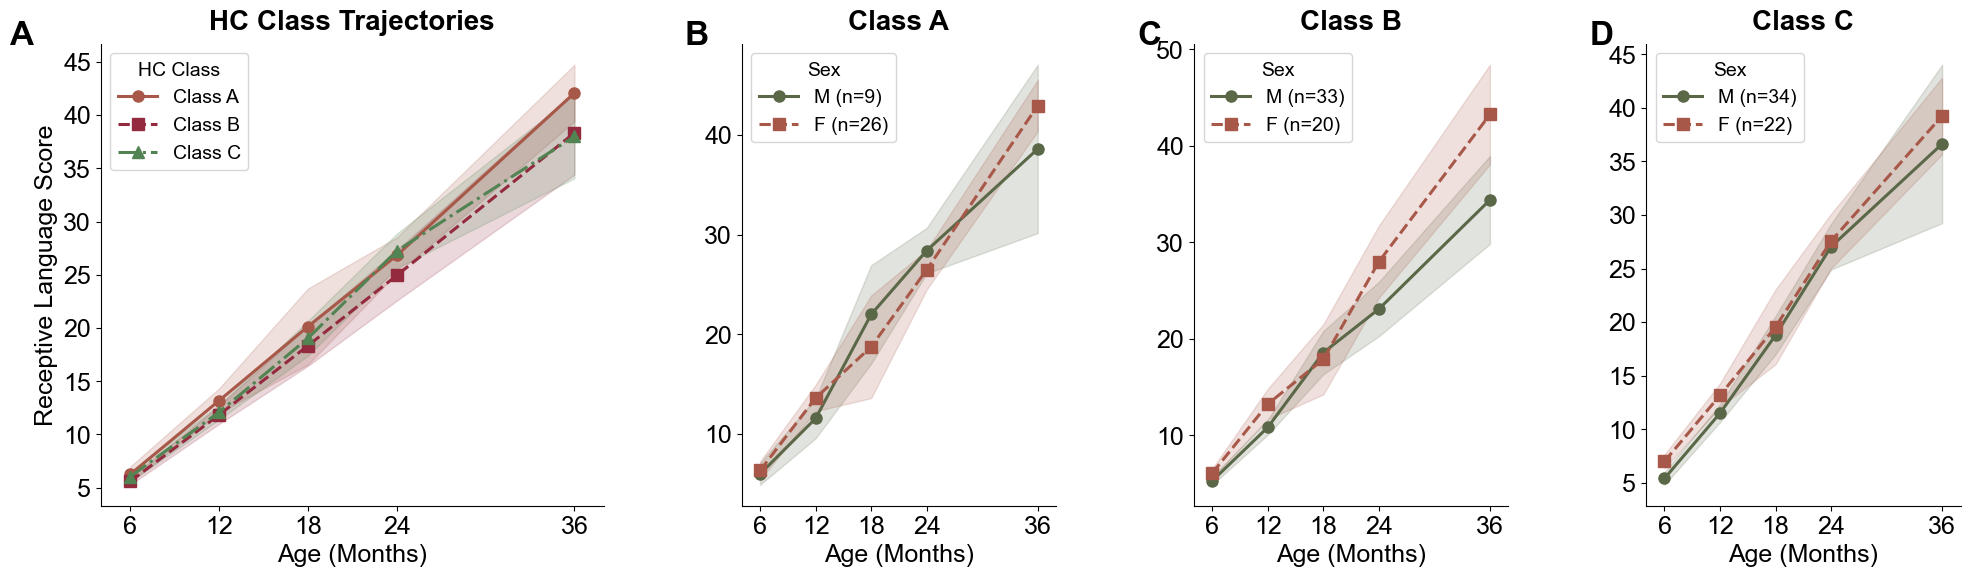

In [ ]:
# ── Expressive Language: HC Class trajectories + sex within each class ────────


plt.rcParams.update({
    'font.family':           'sans-serif',
    'font.sans-serif':       ['Arial', 'Helvetica Neue', 'DejaVu Sans'],
    'font.size':             18,
    'axes.titlesize':        20,
    'axes.titleweight':      'bold',
    'axes.labelsize':        18,
    'xtick.labelsize':       18,
    'ytick.labelsize':       18,
    'legend.fontsize':       14,
    'legend.title_fontsize': 14,
    'axes.spines.top':       False,
    'axes.spines.right':     False,
    'axes.grid':             False,
    'figure.facecolor':      'white',
    'axes.facecolor':        'white',
})

# ── Palettes ──────────────────────────────────────────────────────────────────
# HC class colours — warm neutrals distinct from the M/F sex palette
hc_class_palette = {
    'a': "#A85848",   # muted amber
    'c': "#528352",   # muted sage green
    'b': "#942A3E",   # muted maroon

}
hc_class_ls     = {'a': '-',  'b': '--', 'c': '-.'}
hc_class_marker = {'a': 'o',  'b': 's',  'c': '^'}
hc_class_order  = sorted(receptive_df['HC Class'].dropna().unique())

# Sex colours — reuse M_DARK / F_DARK from main palette
sex_col_palette = {'M': M_DARK,  'F': F_DARK}
sex_col_ls      = {'M': '-',     'F': '--'}
sex_col_marker  = {'M': 'o',     'F': 's'}

# ── Figure — 1 × 4 with Panel A ~1.6× wider than B/C/D ──────────────────────
fig_lang, axs_lang = plt.subplots(
    1, 4,
    figsize=(6.0 * 4, 6.0),
    gridspec_kw={'width_ratios': [1.6, 1, 1, 1],
                 'wspace': 0.38},
)

panel_letters = ['A', 'B', 'C', 'D']

# ── Panel A: HC class overview (both sexes pooled) ────────────────────────────
ax = axs_lang[0]
for cls in hc_class_order:
    sub = receptive_df[receptive_df['HC Class'] == cls]
    grouped = sub.groupby('Age')['score'].agg(['mean', 'sem']).reset_index()
    grouped['ci_lo'] = grouped['mean'] - 1.96 * grouped['sem']
    grouped['ci_hi'] = grouped['mean'] + 1.96 * grouped['sem']
    ax.plot(grouped['Age'], grouped['mean'],
            color=hc_class_palette[cls], linestyle=hc_class_ls[cls],
            marker=hc_class_marker[cls], markersize=8, linewidth=2.2,
            label=f'Class {cls.upper()}')
    ax.fill_between(grouped['Age'], grouped['ci_lo'], grouped['ci_hi'],
                    color=hc_class_palette[cls], alpha=0.18)

ax.set_title('HC Class Trajectories', pad=10)
ax.set_xlabel('Age (Months)')
ax.set_ylabel('Receptive Language Score')
ax.set_xticks(ages)
ax.set_xlim(min(ages) - 2, max(ages) + 2)
ax.legend(title='HC Class', frameon=True, facecolor='white', edgecolor='#cccccc')

# Panel A letter
ax.text(-0.18, 1.05, 'A',
        transform=ax.transAxes,
        fontsize=24, fontweight='bold', va='top', ha='left')

# ── Panels B–D: M vs F within each HC class ───────────────────────────────────
for panel_idx, cls in enumerate(hc_class_order):
    ax = axs_lang[panel_idx + 1]
    sub_cls = receptive_df[receptive_df['HC Class'] == cls].dropna(subset=['sex'])

    for sex in ['M', 'F']:
        sub = sub_cls[sub_cls['sex'] == sex]
        if sub.empty:
            continue
        grouped = sub.groupby('Age')['score'].agg(['mean', 'sem']).reset_index()
        grouped['ci_lo'] = grouped['mean'] - 1.96 * grouped['sem']
        grouped['ci_hi'] = grouped['mean'] + 1.96 * grouped['sem']
        n_sub = sub['subject'].nunique() if 'subject' in sub.columns else len(sub)
        ax.plot(grouped['Age'], grouped['mean'],
                color=sex_col_palette[sex], linestyle=sex_col_ls[sex],
                marker=sex_col_marker[sex], markersize=8, linewidth=2.2,
                label=f'{sex} (n={n_sub})')
        ax.fill_between(grouped['Age'], grouped['ci_lo'], grouped['ci_hi'],
                        color=sex_col_palette[sex], alpha=0.18)

    ax.set_title(f'Class {cls.upper()}', pad=10)
    ax.set_xlabel('Age (Months)')
    ax.set_ylabel('')
    ax.set_xticks(ages)
    ax.set_xlim(min(ages) - 2, max(ages) + 2)
    ax.legend(title='Sex', frameon=True, facecolor='white', edgecolor='#cccccc')

    # Panel letters B, C, D
    ax.text(-0.18, 1.05, panel_letters[panel_idx + 1],
            transform=ax.transAxes,
            fontsize=24, fontweight='bold', va='top', ha='left')



plt.tight_layout()
os.makedirs('../../figures/supplementary/', exist_ok=True)
plt.savefig('../../figures/supplementary/S4_receptive_language_HC_sex_trajectories.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


### **Supplementary S5** Receptive language scores LPA Classes

C:\Users\gabot\AppData\Local\Temp\ipykernel_35956\2914496653.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


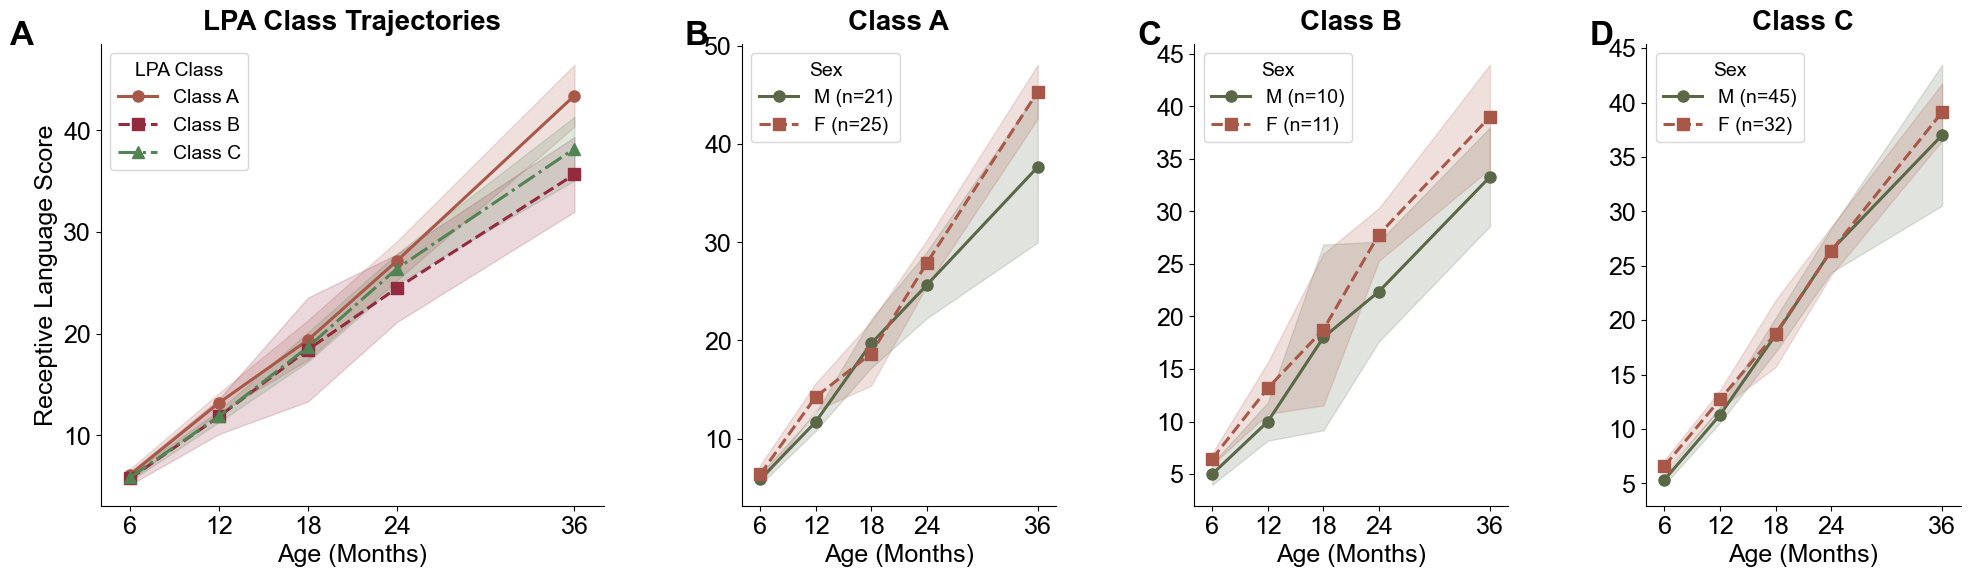

In [291]:
plt.rcParams.update({
    'font.family':           'sans-serif',
    'font.sans-serif':       ['Arial', 'Helvetica Neue', 'DejaVu Sans'],
    'font.size':             18,
    'axes.titlesize':        20,
    'axes.titleweight':      'bold',
    'axes.labelsize':        18,
    'xtick.labelsize':       18,
    'ytick.labelsize':       18,
    'legend.fontsize':       14,
    'legend.title_fontsize': 14,
    'axes.spines.top':       False,
    'axes.spines.right':     False,
    'axes.grid':             False,
    'figure.facecolor':      'white',
    'axes.facecolor':        'white',
})

# ── Palettes ──────────────────────────────────────────────────────────────────
# HC class colours — warm neutrals distinct from the M/F sex palette
hc_class_palette = {
    'A': "#A85848",   # muted amber
    'C': "#528352",   # muted sage green
    'B': "#942A3E",   # muted maroon

}
hc_class_ls     = {'A': '-',  'B': '--', 'C': '-.'}
hc_class_marker = {'A': 'o',  'B': 's',  'C': '^'}
hc_class_order  = sorted(receptive_df['LPA Class'].dropna().unique())

# Sex colours — reuse M_DARK / F_DARK from main palette
sex_col_palette = {'M': M_DARK,  'F': F_DARK}
sex_col_ls      = {'M': '-',     'F': '--'}
sex_col_marker  = {'M': 'o',     'F': 's'}

# ── Figure — 1 × 4 with Panel A ~1.6× wider than B/C/D ──────────────────────
fig_lang, axs_lang = plt.subplots(
    1, 4,
    figsize=(6.0 * 4, 6.0),
    gridspec_kw={'width_ratios': [1.6, 1, 1, 1],
                 'wspace': 0.38},
)

panel_letters = ['A', 'B', 'C', 'D']

# ── Panel A: LPA class overview (both sexes pooled) ────────────────────────────
ax = axs_lang[0]
for cls in hc_class_order:
    sub = receptive_df[receptive_df['LPA Class'] == cls]
    grouped = sub.groupby('Age')['score'].agg(['mean', 'sem']).reset_index()
    grouped['ci_lo'] = grouped['mean'] - 1.96 * grouped['sem']
    grouped['ci_hi'] = grouped['mean'] + 1.96 * grouped['sem']
    ax.plot(grouped['Age'], grouped['mean'],
            color=hc_class_palette[cls], linestyle=hc_class_ls[cls],
            marker=hc_class_marker[cls], markersize=8, linewidth=2.2,
            label=f'Class {cls.upper()}')
    ax.fill_between(grouped['Age'], grouped['ci_lo'], grouped['ci_hi'],
                    color=hc_class_palette[cls], alpha=0.18)

ax.set_title('LPA Class Trajectories', pad=10)
ax.set_xlabel('Age (Months)')
ax.set_ylabel('Receptive Language Score')
ax.set_xticks(ages)
ax.set_xlim(min(ages) - 2, max(ages) + 2)
ax.legend(title='LPA Class', frameon=True, facecolor='white', edgecolor='#cccccc')

# Panel A letter
ax.text(-0.18, 1.05, 'A',
        transform=ax.transAxes,
        fontsize=24, fontweight='bold', va='top', ha='left')

# ── Panels B–D: M vs F within each LPA class ───────────────────────────────────
for panel_idx, cls in enumerate(hc_class_order):
    ax = axs_lang[panel_idx + 1]
    sub_cls = receptive_df[receptive_df['LPA Class'] == cls].dropna(subset=['sex'])

    for sex in ['M', 'F']:
        sub = sub_cls[sub_cls['sex'] == sex]
        if sub.empty:
            continue
        grouped = sub.groupby('Age')['score'].agg(['mean', 'sem']).reset_index()
        grouped['ci_lo'] = grouped['mean'] - 1.96 * grouped['sem']
        grouped['ci_hi'] = grouped['mean'] + 1.96 * grouped['sem']
        n_sub = sub['subject'].nunique() if 'subject' in sub.columns else len(sub)
        ax.plot(grouped['Age'], grouped['mean'],
                color=sex_col_palette[sex], linestyle=sex_col_ls[sex],
                marker=sex_col_marker[sex], markersize=8, linewidth=2.2,
                label=f'{sex} (n={n_sub})')
        ax.fill_between(grouped['Age'], grouped['ci_lo'], grouped['ci_hi'],
                        color=sex_col_palette[sex], alpha=0.18)

    ax.set_title(f'Class {cls.upper()}', pad=10)
    ax.set_xlabel('Age (Months)')
    ax.set_ylabel('')
    ax.set_xticks(ages)
    ax.set_xlim(min(ages) - 2, max(ages) + 2)
    ax.legend(title='Sex', frameon=True, facecolor='white', edgecolor='#cccccc')

    # Panel letters B, C, D
    ax.text(-0.18, 1.05, panel_letters[panel_idx + 1],
            transform=ax.transAxes,
            fontsize=24, fontweight='bold', va='top', ha='left')



plt.tight_layout()
os.makedirs('../../figures/supplementary/', exist_ok=True)
plt.savefig('../../figures/supplementary/S5_receptive_language_LPA_sex_trajectories.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


### **Supplementary S6** Expressive language scores LPA Classes

C:\Users\gabot\AppData\Local\Temp\ipykernel_35956\3268474851.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


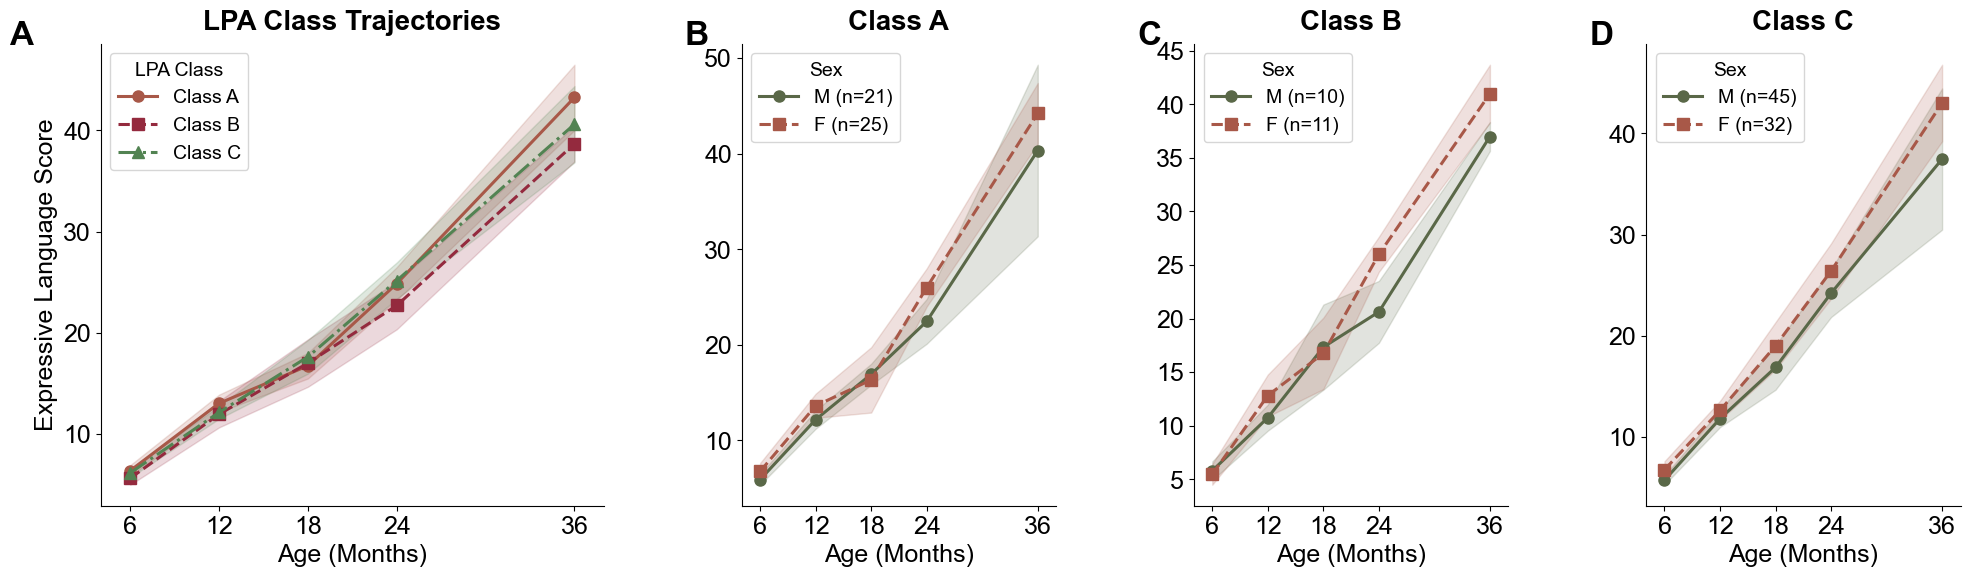

In [292]:
plt.rcParams.update({
    'font.family':           'sans-serif',
    'font.sans-serif':       ['Arial', 'Helvetica Neue', 'DejaVu Sans'],
    'font.size':             18,
    'axes.titlesize':        20,
    'axes.titleweight':      'bold',
    'axes.labelsize':        18,
    'xtick.labelsize':       18,
    'ytick.labelsize':       18,
    'legend.fontsize':       14,
    'legend.title_fontsize': 14,
    'axes.spines.top':       False,
    'axes.spines.right':     False,
    'axes.grid':             False,
    'figure.facecolor':      'white',
    'axes.facecolor':        'white',
})

# ── Palettes ──────────────────────────────────────────────────────────────────
# HC class colours — warm neutrals distinct from the M/F sex palette
hc_class_palette = {
    'A': "#A85848",   # muted amber
    'C': "#528352",   # muted sage green
    'B': "#942A3E",   # muted maroon

}
hc_class_ls     = {'A': '-',  'B': '--', 'C': '-.'}
hc_class_marker = {'A': 'o',  'B': 's',  'C': '^'}
hc_class_order  = sorted(expressive_df['LPA Class'].dropna().unique())

# Sex colours — reuse M_DARK / F_DARK from main palette
sex_col_palette = {'M': M_DARK,  'F': F_DARK}
sex_col_ls      = {'M': '-',     'F': '--'}
sex_col_marker  = {'M': 'o',     'F': 's'}

# ── Figure — 1 × 4 with Panel A ~1.6× wider than B/C/D ──────────────────────
fig_lang, axs_lang = plt.subplots(
    1, 4,
    figsize=(6.0 * 4, 6.0),
    gridspec_kw={'width_ratios': [1.6, 1, 1, 1],
                 'wspace': 0.38},
)

panel_letters = ['A', 'B', 'C', 'D']

# ── Panel A: LPA class overview (both sexes pooled) ────────────────────────────
ax = axs_lang[0]
for cls in hc_class_order:
    sub = expressive_df[expressive_df['LPA Class'] == cls]
    grouped = sub.groupby('Age')['score'].agg(['mean', 'sem']).reset_index()
    grouped['ci_lo'] = grouped['mean'] - 1.96 * grouped['sem']
    grouped['ci_hi'] = grouped['mean'] + 1.96 * grouped['sem']
    ax.plot(grouped['Age'], grouped['mean'],
            color=hc_class_palette[cls], linestyle=hc_class_ls[cls],
            marker=hc_class_marker[cls], markersize=8, linewidth=2.2,
            label=f'Class {cls.upper()}')
    ax.fill_between(grouped['Age'], grouped['ci_lo'], grouped['ci_hi'],
                    color=hc_class_palette[cls], alpha=0.18)

ax.set_title('LPA Class Trajectories', pad=10)
ax.set_xlabel('Age (Months)')
ax.set_ylabel('Expressive Language Score')
ax.set_xticks(ages)
ax.set_xlim(min(ages) - 2, max(ages) + 2)
ax.legend(title='LPA Class', frameon=True, facecolor='white', edgecolor='#cccccc')

# Panel A letter
ax.text(-0.18, 1.05, 'A',
        transform=ax.transAxes,
        fontsize=24, fontweight='bold', va='top', ha='left')

# ── Panels B–D: M vs F within each LPA class ───────────────────────────────────
for panel_idx, cls in enumerate(hc_class_order):
    ax = axs_lang[panel_idx + 1]
    sub_cls = expressive_df[expressive_df['LPA Class'] == cls].dropna(subset=['sex'])

    for sex in ['M', 'F']:
        sub = sub_cls[sub_cls['sex'] == sex]
        if sub.empty:
            continue
        grouped = sub.groupby('Age')['score'].agg(['mean', 'sem']).reset_index()
        grouped['ci_lo'] = grouped['mean'] - 1.96 * grouped['sem']
        grouped['ci_hi'] = grouped['mean'] + 1.96 * grouped['sem']
        n_sub = sub['subject'].nunique() if 'subject' in sub.columns else len(sub)
        ax.plot(grouped['Age'], grouped['mean'],
                color=sex_col_palette[sex], linestyle=sex_col_ls[sex],
                marker=sex_col_marker[sex], markersize=8, linewidth=2.2,
                label=f'{sex} (n={n_sub})')
        ax.fill_between(grouped['Age'], grouped['ci_lo'], grouped['ci_hi'],
                        color=sex_col_palette[sex], alpha=0.18)

    ax.set_title(f'Class {cls.upper()}', pad=10)
    ax.set_xlabel('Age (Months)')
    ax.set_ylabel('')
    ax.set_xticks(ages)
    ax.set_xlim(min(ages) - 2, max(ages) + 2)
    ax.legend(title='Sex', frameon=True, facecolor='white', edgecolor='#cccccc')

    # Panel letters B, C, D
    ax.text(-0.18, 1.05, panel_letters[panel_idx + 1],
            transform=ax.transAxes,
            fontsize=24, fontweight='bold', va='top', ha='left')



plt.tight_layout()
os.makedirs('../../figures/supplementary/', exist_ok=True)
plt.savefig('../../figures/supplementary/S6_expressive_language_LPA_sex_trajectories.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


## Individual trajectories

C:\Users\gabot\AppData\Local\Temp\ipykernel_21328\954663906.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


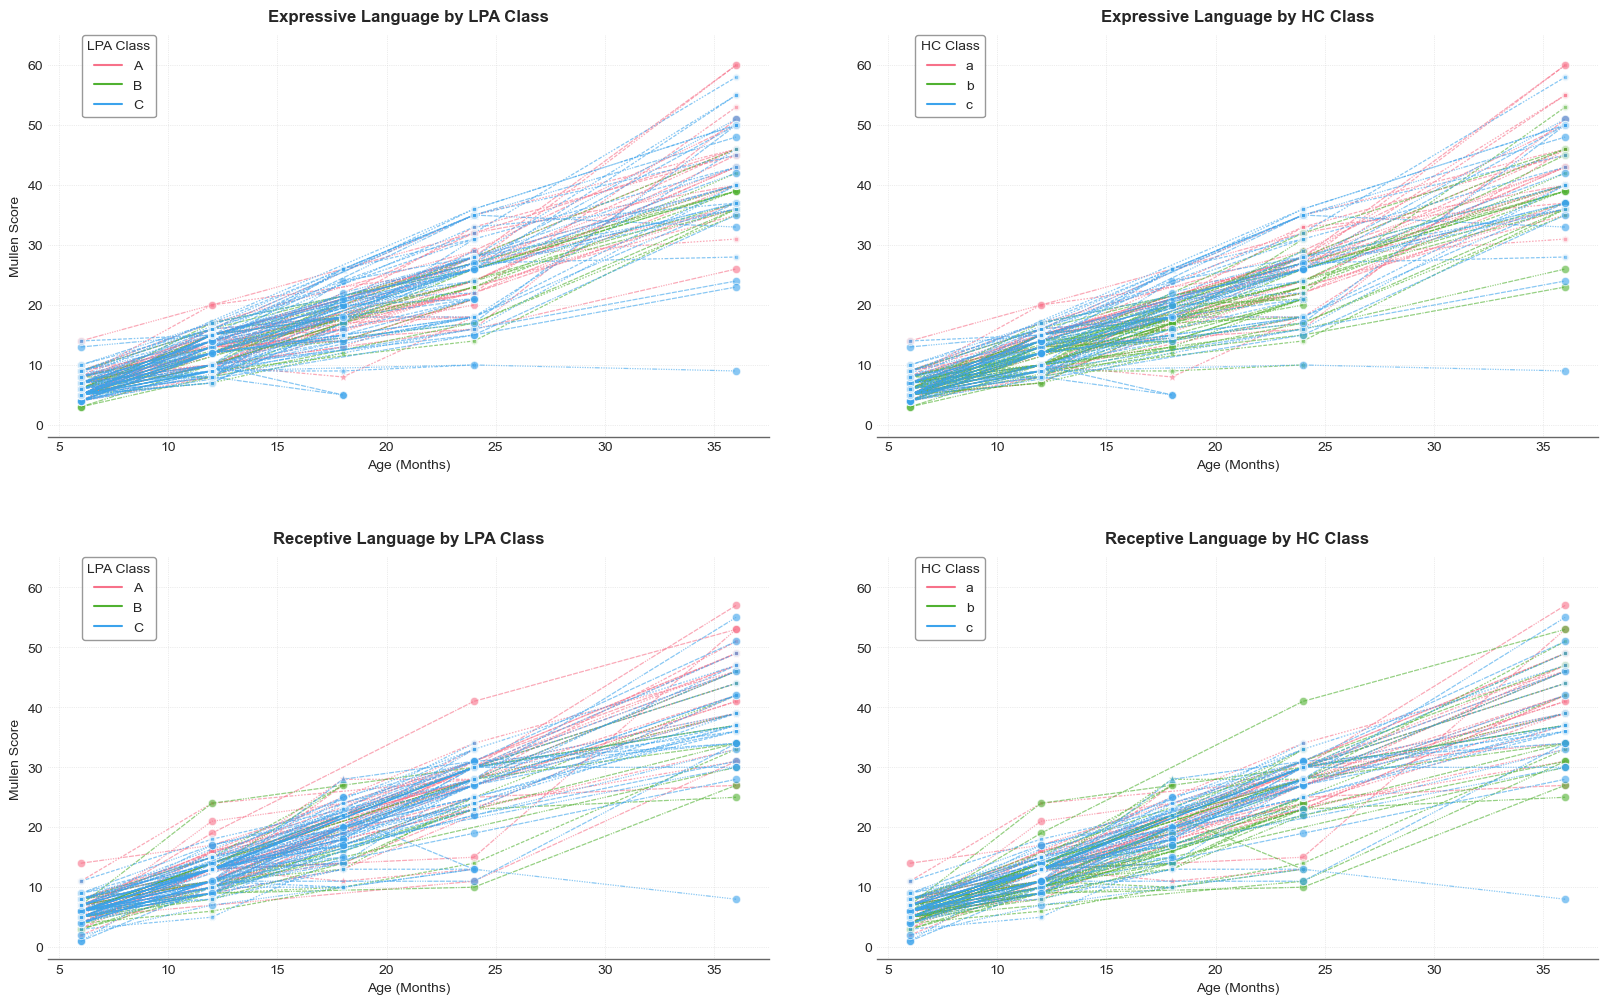

In [100]:
sns.set_style("whitegrid", {'grid.linestyle': ':', 'axes.edgecolor': '0.4'})
#plt.rcParams['font.family'] = 'Arial'  # Professional font
class_palette =  sns.color_palette("husl", 3)  # Can be any of : "viridis", "husl", "colorblind", "cool", "muted"
# Create figure with constrained layout
fig, axs = plt.subplots(2, 2, figsize=(20, 12), 
                        gridspec_kw={'wspace': 0.15, 'hspace': 0.3})
axs = axs.flatten()

# Use perceptually uniform palette
subject_style = {'dashes': True, 'linewidth': 0.9, 'alpha': 0.6}

# --- Plot 1: Expressive by LPA ---
g1 = sns.lineplot(data=expressive_df, x="Age", y="score", hue="LPA Class", 
                 palette=class_palette, style="subject", markers=True,
                 ax=axs[0], **subject_style)
axs[0].set_title("Expressive Language by LPA Class", pad=10, weight='bold')
axs[0].set(ylabel="Mullen Score", xlabel="Age (Months)")

# --- Plot 2: Expressive by HC ---
g2 = sns.lineplot(data=expressive_df, x="Age", y="score", hue="HC Class", 
                 palette=class_palette, style="subject", markers=True,
                 ax=axs[1], **subject_style)
axs[1].set_title("Expressive Language by HC Class", pad=10, weight='bold')
axs[1].set(ylabel="", xlabel="Age (Months)")

# --- Plot 3: Receptive by LPA ---
g3 = sns.lineplot(data=receptive_df, x="Age", y="score", hue="LPA Class", 
                palette=class_palette, style="subject", markers=True,
                ax=axs[2], **subject_style)
axs[2].set_title("Receptive Language by LPA Class", pad=10, weight='bold')
axs[2].set(ylabel="Mullen Score", xlabel="Age (Months)")

# --- Plot 4: Receptive by HC ---
g4 = sns.lineplot(data=receptive_df, x="Age", y="score", hue="HC Class", 
                palette=class_palette, style="subject", markers=True,
                ax=axs[3], **subject_style)
axs[3].set_title("Receptive Language by HC Class", pad=10, weight='bold')
axs[3].set(ylabel="", xlabel="Age (Months)")

# --- Custom Legend Handling ---
def create_combined_legend(ax, title):
    # Get all handles and labels from seaborn
    class_handles, class_labels = ax.get_legend_handles_labels()
    
    # Filter to keep only hue-related entries (e.g., only alphabetical class labels or known hue names)
    class_handles_labels = [(h, l) for h, l in zip(class_handles, class_labels)
                            if l in ['A', 'B', 'C', 'a', 'b', 'c']]  # Keep only known hue names
    # Remove duplicates while preserving order
    seen = set()
    class_handles_labels = [(h, l) for h, l in class_handles_labels if not (l in seen or seen.add(l))]

    
    # Unzip filtered pairs
    if class_handles_labels:  # Ensure list isn't empty
        class_handles, class_labels = zip(*class_handles_labels)

        # Create custom legend
        leg = ax.legend(class_handles, class_labels, title=title, 
                        frameon=True, bbox_to_anchor=(0.15, 1), 
                        borderaxespad=0.)
        leg.get_frame().set_edgecolor('0.5')
        return leg
    else:
        return None

# Add legends to each subplot
create_combined_legend(axs[0], "LPA Class")
create_combined_legend(axs[1], "HC Class")
create_combined_legend(axs[2], "LPA Class")
create_combined_legend(axs[3], "HC Class")

for ax in axs:
    # Cleaner spines
    sns.despine(ax=ax, left=True)
    
    # Add subtle grid
    ax.grid(True, linestyle=':', linewidth=0.5, alpha=0.7)
    
    # Set consistent axis limits
    ax.set_ylim(expressive_df['score'].min()-5, expressive_df['score'].max()+5)


plt.tight_layout()

# Save the figure
plt.savefig(f"../../Figures/Supplementary/{date}/individual_language_trajectories_{date}.png", dpi=300, bbox_inches='tight')
plt.show()

### **ANOVA/KRUSTAL W ANALYSES**

In [128]:

def analyze_language_data(expressive_df, receptive_df, ages=[24, 36], output_dir="../../", date=date):
    """
    Analyze language data across different age groups and classification methods.
    
    Parameters:
    -----------
    expressive_df : pandas DataFrame
        DataFrame containing expressive language scores
    receptive_df : pandas DataFrame
        DataFrame containing receptive language scores
    ages : list, optional
        List of ages (in months) to analyze
    output_dir : str, optional
        Base directory for output files
    date : str, optional
        Date string for file naming
    """
    # Create output directories if they don't exist
    tables_dir = os.path.join(output_dir, "Tables", "Supplementary", date)
    figures_dir = os.path.join(output_dir, "Figures", "Supplementary", date)
    
    for directory in [tables_dir, figures_dir]:
        os.makedirs(directory, exist_ok=True)
    
    # Initialize results file
    results_file = os.path.join(tables_dir, f"language_analysis_results_{date}.txt")
    with open(results_file, 'w') as f:
        f.write(f"Language Measures Analysis Results - {date}\n")
        f.write("="*50 + "\n\n")
    
    for age in ages:
        print(f"\nAnalyzing data for {age} months...")
        
        # Filter data for the current age
        expr_age = expressive_df[expressive_df['Age'] == age].copy()
        recp_age = receptive_df[receptive_df['Age'] == age].copy()

        # Drop nan values
        expr_age = expr_age.dropna(subset=['score'])
        recp_age = recp_age.dropna(subset=['score'])
        
        # Run analyses for all four combinations
        expr_lpa_results = analyze_group_differences(expr_age, "Expressive", "LPA", results_file)
        expr_hc_results = analyze_group_differences(expr_age, "Expressive", "HC", results_file)
        recp_lpa_results = analyze_group_differences(recp_age, "Receptive", "LPA", results_file)
        recp_hc_results = analyze_group_differences(recp_age, "Receptive", "HC", results_file)

        # Print results to console
        print(f"\nSummary of findings for {age} months:")
        for result in [expr_lpa_results, expr_hc_results, recp_lpa_results, recp_hc_results]:
            print(result)

        # Create visualizations
        create_visualization(expr_age, recp_age, age, figures_dir, date)
        
        # Create and save summary table
        create_summary_table(expr_age, recp_age, age, tables_dir, date)
    
    print(f"\nAnalysis complete. Results saved to: {tables_dir} and {figures_dir}")


def analyze_group_differences(data, measure_type, stratification, results_file):
    """
    Check ANOVA assumptions and perform appropriate statistical tests.
    
    Parameters:
    -----------
    data : pandas DataFrame
        The data to analyze
    measure_type : str
        Type of language measure (e.g., "Expressive", "Receptive")
    stratification : str
        Stratification method (e.g., "LPA", "HC")
    results_file : str
        Path to the file where results will be saved
    
    Returns:
    --------
    str
        Text summary of the analysis results
    """
    age = data['Age'].iloc[0] if not data.empty else "Unknown"
    result_text = f"\n{measure_type} Language by {stratification} Class at {age} Months\n"
    result_text += "-"*50 + "\n"
    
    # Group variable name (either "LPA Class" or "HC Class")
    group_var = f"{stratification} Class"
    
    # Check if there is sufficient data
    if data.empty or group_var not in data.columns:
        result_text += "Insufficient data for analysis.\n"
        with open(results_file, 'a') as f:
            f.write(result_text)
        return result_text
    
    # Get unique groups
    groups = data[group_var].unique()
    
    # 1. Check normality assumption for each group
    result_text += "Normality Test (Shapiro-Wilk):\n"
    all_normal = True
    
    for group in groups:
        group_data = data[data[group_var] == group]['score']
        if len(group_data) >= 3:  # Need at least 3 data points for Shapiro-Wilk
            stat, p = stats.shapiro(group_data)
            normal = p > 0.05
            all_normal = all_normal and normal
            result_text += f"  Group {group}: W={stat:.4f}, p={p:.4f}, {'Normal' if normal else 'Non-normal'}\n"
        else:
            result_text += f"  Group {group}: Insufficient data for normality test (n={len(group_data)})\n"
            all_normal = False
    
    # 2. Check homogeneity of variance
    if len(groups) >= 2:
        # Extract groups for Levene's test
        group_data = [data[data[group_var] == group]['score'].values for group in groups]
        # Remove empty groups
        group_data = [g for g in group_data if len(g) > 0]
        
        if len(group_data) >= 2:  # Need at least 2 groups for test
            stat, p = stats.levene(*group_data)
            equal_var = p > 0.05
            result_text += f"\nHomogeneity of Variance (Levene's test):\n"
            result_text += f"  W={stat:.4f}, p={p:.4f}, {'Equal variances' if equal_var else 'Unequal variances'}\n"
        else:
            equal_var = True  # Default
            result_text += "\nHomogeneity of Variance: Insufficient groups for testing\n"
    else:
        equal_var = True  # Default
        result_text += "\nHomogeneity of Variance: Insufficient groups for testing\n"
    
    # 3. Perform appropriate statistical test
    if len(groups) >= 2:
        if all_normal and equal_var:
            # Create a copy of data with renamed column for statsmodels
            temp_data = data.copy()
            # Replace spaces with underscores in column names
            temp_data.columns = [col.replace(' ', '_') for col in temp_data.columns]
            group_var_no_space = group_var.replace(' ', '_')
            
            # One-way ANOVA with renamed columns
            model = ols(f'score ~ C({group_var_no_space})', data=temp_data).fit()
            anova_results = anova_lm(model)
            
            result_text += "\nOne-way ANOVA Results:\n"
            result_text += f"  F({anova_results.loc[f'C({group_var_no_space})', 'df']:.0f}, {anova_results.loc['Residual', 'df']:.0f}) = {anova_results.loc[f'C({group_var_no_space})', 'F']:.4f}, "
            result_text += f"p = {anova_results.loc[f'C({group_var_no_space})', 'PR(>F)']:.4f}\n"
            
            # Add effect size (eta-squared)
            eta_sq = anova_results.loc[f'C({group_var_no_space})', 'sum_sq'] / (anova_results.loc[f'C({group_var_no_space})', 'sum_sq'] + anova_results.loc['Residual', 'sum_sq'])
            result_text += f"  Eta-squared = {eta_sq:.4f}\n"
            
            # If ANOVA is significant, perform post-hoc tests
            if anova_results.loc[f'C({group_var_no_space})', 'PR(>F)'] < 0.05:
                result_text += "\nPost-hoc Tests (Tukey HSD):\n"
                # For post-hoc tests, use original data and column names
                posthoc = pg.pairwise_tukey(data=data, dv='score', between=group_var)
                for idx, row in posthoc.iterrows():
                    result_text += f"  {row['A']} vs {row['B']}: diff={row['diff']:.4f}, p={row['p-tukey']:.4f}\n"
        else:
            # Kruskal-Wallis test (non-parametric alternative to ANOVA)
            valid_groups = [data[data[group_var] == group]['score'].values for group in groups if len(data[data[group_var] == group]) > 0]
            h_stat, p_val = stats.kruskal(*valid_groups)
            
            result_text += "\nKruskal-Wallis Test Results (non-parametric):\n"
            result_text += f"  H = {h_stat:.4f}, p = {p_val:.4f}\n"
            
            # If significant, perform post-hoc Dunn's test
            if p_val < 0.05:
                result_text += "\nPost-hoc Tests (Dunn's test):\n"
                try:
                    # Use dunn's test from scikit-posthocs as a safer alternative
                    from scikit_posthocs import posthoc_dunn
                    # Create a DataFrame with group labels
                    temp_df = data.copy()
                    posthoc_data = posthoc_dunn(temp_df, val_col='score', group_col=group_var, p_adjust='bonferroni')
                    
                    # Format the results
                    for i, group1 in enumerate(posthoc_data.index):
                        for j, group2 in enumerate(posthoc_data.columns):
                            if i < j:  # Only show each pair once
                                p_val = posthoc_data.iloc[i, j]
                                result_text += f"  {group1} vs {group2}: p={p_val:.4f}\n"
                except ImportError:
                    # Fallback to pingouin but handle the column naming issue
                    posthoc = pg.pairwise_tests(data=data, dv='score', between=group_var, parametric=False)
                    
                    # Debug column names
                    result_text += "  Available columns in post-hoc results: " + ", ".join(posthoc.columns.tolist()) + "\n\n"
                    
                    # Use correct column name for adjusted p-values
                    p_adj_col = 'p-corr' if 'p-corr' in posthoc.columns else 'p-adjust' if 'p-adjust' in posthoc.columns else 'p-unc'
                    
                    for idx, row in posthoc.iterrows():
                        result_text += f"  {row['A']} vs {row['B']}: p={row[p_adj_col]:.4f}\n"
    else:
        result_text += "\nInsufficient groups for statistical comparison\n"
    
    # 4. Descriptive statistics
    result_text += "\nDescriptive Statistics:\n"
    desc_stats = data.groupby(group_var)['score'].agg(['count', 'mean', 'std', 'min', 'max']).reset_index()
    for _, row in desc_stats.iterrows():
        result_text += f"  Group {row[group_var]}: n={row['count']}, Mean={row['mean']:.2f}, SD={row['std']:.2f}, Range={row['min']:.2f}-{row['max']:.2f}\n"
    
    # Write to file
    with open(results_file, 'a') as f:
        f.write(result_text)
    
    return result_text


def create_visualization(expr_data, recp_data, age, figures_dir, date):
    """
    Create and save visualization of language scores by group.
    
    Parameters:
    -----------
    expr_data : pandas DataFrame
        DataFrame containing expressive language scores
    recp_data : pandas DataFrame
        DataFrame containing receptive language scores
    age : int
        Age in months
    figures_dir : str
        Directory where figures will be saved
    date : str
        Date string for file naming
    """
    # Set up professional style - use a safer approach
    sns.set_style("whitegrid")
    sns.set_context("paper", font_scale=1.2)
    
    # Use a colorblind-friendly palette
    class_palette = sns.color_palette("viridis", n_colors=3)  # Can be any of : "viridis", "husl", "colorblind", "cool
    
    # Create figure with constrained layout
    fig, axs = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

    # Add more spece between subplots   
    fig.subplots_adjust(hspace=0.3, wspace=0.2, top=0.9)
    axs = axs.flatten()
    
    # Create boxplots
    create_boxplot(axs[0], expr_data, "LPA Class", f"Expressive Language by LPA Class at {age} Months", class_palette)
    create_boxplot(axs[1], expr_data, "HC Class", f"Expressive Language by HC Class at {age} Months", class_palette)
    create_boxplot(axs[2], recp_data, "LPA Class", f"Receptive Language by LPA Class at {age} Months", class_palette)
    create_boxplot(axs[3], recp_data, "HC Class", f"Receptive Language by HC Class at {age} Months", class_palette)
    
    # Add figure title
    fig.suptitle(f"Language Scores at {age} Months by Classification Method", 
                fontsize=15, weight='bold', y=1.08)
    
    # Save the figure
    output_file = os.path.join(figures_dir, f"language_analysis_{age}months_{date}.png")
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    try:
        plt.savefig(output_file.replace('.png', '.pdf'), format='pdf', bbox_inches='tight')  # Also save as PDF for publication
    except Exception as e:
        print(f"Warning: Could not save PDF version: {e}")
    plt.close()
    
    print(f"Created visualization: {output_file}")


def create_boxplot(ax, data, group_var, title, palette):
    """
    Create a boxplot with data points for a specific group variable.
    
    Parameters:
    -----------
    ax : matplotlib.axes.Axes
        The axes to plot on
    data : pandas DataFrame
        The data to plot
    group_var : str
        The grouping variable
    title : str
        The title for the plot
    palette : list
        Color palette to use
    """
    if group_var not in data.columns or data.empty:
        ax.text(0.5, 0.5, "Insufficient data", ha='center', va='center', fontsize=12)
        ax.set_title(title)
        return
    
    # Create boxplot with individual data points
    sns.boxplot(x=group_var, y='score', data=data, palette=palette, ax=ax, width=0.5, fliersize=0)
    sns.stripplot(x=group_var, y='score', data=data, palette=palette, ax=ax, 
                dodge=True, alpha=0.7, jitter=0.2, marker='o', edgecolor='black', linewidth=0.5)
    
    # Set title and labels
    ax.set_title(title, pad=10)
    ax.set_ylabel("Mullen Score")
    ax.set_xlabel("")
    
    # Add statistics annotation
    add_stats_annotation(ax, data, group_var)
    
    # Clean up plot
    sns.despine(ax=ax)
    ax.grid(True, linestyle=':', linewidth=0.5, alpha=0.7)


def add_stats_annotation(ax, data, group_var):
    """
    Add statistical annotation to a plot.
    
    Parameters:
    -----------
    ax : matplotlib.axes.Axes
        The axes to annotate
    data : pandas DataFrame
        The data used in the plot
    group_var : str
        The grouping variable
    """
    # Get number of groups
    groups = data[group_var].unique()
    
    # Prepare annotation text based on test results
    if len(groups) >= 2:
        # Extract data for statistical test
        group_data = [data[data[group_var] == group]['score'].values for group in groups if len(data[data[group_var] == group]) > 0]
        
        # Check normality and homogeneity
        try:
            normal = all([stats.shapiro(g)[1] > 0.05 for g in group_data if len(g) >= 3])
        except:
            normal = False  # Default to non-parametric if there's an issue
            
        if len(group_data) >= 2:
            try:
                equal_var = stats.levene(*group_data)[1] > 0.05
            except:
                equal_var = False  # Default to non-parametric if there's an issue
        else:
            equal_var = True
        
        # Run appropriate test
        if normal and equal_var:
            # One-way ANOVA - using renamed columns to avoid space issues
            try:
                temp_data = data.copy()
                temp_data.columns = [col.replace(' ', '_') for col in temp_data.columns]
                group_var_no_space = group_var.replace(' ', '_')
                
                model = ols(f'score ~ C({group_var_no_space})', data=temp_data).fit()
                anova_table = anova_lm(model)
                p_val = anova_table.loc[f'C({group_var_no_space})', 'PR(>F)']
                test_name = "ANOVA"
                test_stat = f"F={anova_table.loc[f'C({group_var_no_space})', 'F']:.2f}"
            except Exception as e:
                # Fall back to Kruskal-Wallis if ANOVA fails
                try:
                    h_stat, p_val = stats.kruskal(*group_data)
                    test_name = "Kruskal-Wallis"
                    test_stat = f"H={h_stat:.2f}"
                except:
                    p_val = np.nan
                    test_name = "Error"
                    test_stat = ""
        else:
            # Kruskal-Wallis
            try:
                h_stat, p_val = stats.kruskal(*group_data)
                test_name = "Kruskal-Wallis"
                test_stat = f"H={h_stat:.2f}"
            except:
                p_val = np.nan
                test_name = "Error"
                test_stat = ""
        
        # Format annotation based on significance
        if not pd.isna(p_val):
            if p_val < 0.001:
                sig_text = f"{test_name}: {test_stat}, p<0.001 ***"
            elif p_val < 0.01:
                sig_text = f"{test_name}: {test_stat}, p<0.01 **"
            elif p_val < 0.05:
                sig_text = f"{test_name}: {test_stat}, p<0.05 *"
            else:
                sig_text = f"{test_name}: {test_stat}, p={p_val:.3f} ns"
        else:
            sig_text = f"{test_name}: Could not calculate"
            
        # Add text to plot
        ax.text(0.5, 0.98, sig_text, transform=ax.transAxes, 
                ha='center', va='top', fontsize=9, 
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.5'))


def create_summary_table(expr_data, recp_data, age, tables_dir, date):
    """
    Create and save a summary table of results.
    
    Parameters:
    -----------
    expr_data : pandas DataFrame
        DataFrame containing expressive language scores
    recp_data : pandas DataFrame
        DataFrame containing receptive language scores
    age : int
        Age in months
    tables_dir : str
        Directory where tables will be saved
    date : str
        Date string for file naming
    """
    summary_data = []

    for df, measure, strat in [(expr_data, "Expressive", "LPA"), 
                              (expr_data, "Expressive", "HC"),
                              (recp_data, "Receptive", "LPA"),
                              (recp_data, "Receptive", "HC")]:
        
        group_var = f"{strat} Class"
        
        # Skip if data is insufficient
        if group_var not in df.columns or df.empty:
            continue
            
        # Get descriptive stats by group
        desc = df.groupby(group_var)['score'].agg(['count', 'mean', 'std']).reset_index()
        
        # Get statistical test results
        groups = df[group_var].unique()
        test_stat = np.nan
        p_val = np.nan
        test_type = "N/A"
        df_val = np.nan
        
        if len(groups) >= 2:
            # Extract data for test
            group_data = [df[df[group_var] == group]['score'].values for group in groups if len(df[df[group_var] == group]) > 0]
            
            # Check normality and homogeneity
            try:
                normal = all([stats.shapiro(g)[1] > 0.05 for g in group_data if len(g) >= 3])
            except:
                normal = False
                
            if len(group_data) >= 2:
                try:
                    equal_var = stats.levene(*group_data)[1] > 0.05
                except:
                    equal_var = False
            else:
                equal_var = True
            
            # Run appropriate test
            if normal and equal_var:
                try:
                    # ANOVA - using renamed columns to avoid space issues
                    temp_data = df.copy()
                    temp_data.columns = [col.replace(' ', '_') for col in temp_data.columns]
                    group_var_no_space = group_var.replace(' ', '_')
                    
                    model = ols(f'score ~ C({group_var_no_space})', data=temp_data).fit()
                    test_results = anova_lm(model)
                    p_val = test_results.loc[f'C({group_var_no_space})', 'PR(>F)']
                    test_stat = test_results.loc[f'C({group_var_no_space})', 'F']
                    test_type = "ANOVA (F)"
                    df_val = f"{test_results.loc[f'C({group_var_no_space})', 'df']:.0f}, {test_results.loc['Residual', 'df']:.0f}"
                except:
                    # Fall back to Kruskal-Wallis
                    try:
                        test_stat, p_val = stats.kruskal(*group_data)
                        test_type = "Kruskal-Wallis (H)"
                        df_val = len(groups) - 1  # df for Kruskal-Wallis is k-1
                    except:
                        test_stat = np.nan
                        p_val = np.nan
                        test_type = "Error in analysis"
            else:
                # Kruskal-Wallis
                try:
                    test_stat, p_val = stats.kruskal(*group_data)
                    test_type = "Kruskal-Wallis (H)"
                    df_val = len(groups) - 1  # df for Kruskal-Wallis is k-1
                except:
                    test_stat = np.nan
                    p_val = np.nan
                    test_type = "Error in analysis"
        
        # Add to summary data
        for _, row in desc.iterrows():
            summary_data.append({
                'Age': age,
                'Measure': measure,
                'Stratification': strat,
                'Group': row[group_var],
                'N': row['count'],
                'Mean': row['mean'],
                'SD': row['std'],
                'Test': test_type if _ == 0 else "",  # Only include test info once per stratification
                'df': df_val if _ == 0 else np.nan,
                'Statistic': test_stat if _ == 0 else np.nan,
                'p-value': p_val if _ == 0 else np.nan,
                'Significance': get_significance_marker(p_val) if _ == 0 else ""
            })

    # Create and save summary table
    if summary_data:
        summary_df = pd.DataFrame(summary_data)
        
        # Format numeric columns
        summary_df['Mean'] = summary_df['Mean'].round(2)
        summary_df['SD'] = summary_df['SD'].round(2)
        summary_df['Statistic'] = summary_df['Statistic'].apply(lambda x: round(x, 2) if pd.notnull(x) else x)
        
        # Format p-values
        summary_df['p-value'] = summary_df['p-value'].apply(lambda x: format_p_value(x) if not pd.isna(x) else x)
        
        # Save as CSV
        output_file = os.path.join(tables_dir, f"Language_analysis_summary_{age}mo_{date}.csv")
        #summary_df.to_csv(output_file, index=False)
        
        # Also save as Excel for easier editing
        try:
            summary_df.to_excel(output_file.replace('.csv', '.xlsx'), index=False)
        except:
            print(f"Warning: Could not save Excel file. Make sure openpyxl is installed.")
        
        print(f"Created summary table: {output_file}")
    else:
        print(f"Insufficient data to create summary table for age {age} months")


def get_significance_marker(p_value):
    """Return significance marker based on p-value."""
    if pd.isna(p_value):
        return ""
    elif p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return "ns"


def format_p_value(p_value):
    """Format p-value for reporting."""
    if pd.isna(p_value):
        return ""
    elif p_value < 0.001:
        return "<0.001"
    else:
        return f"{p_value:.3f}"
analyze_language_data(expressive_df, receptive_df, ages=[12,24, 36], output_dir="../../", date=date)


Analyzing data for 12 months...



Summary of findings for 12 months:

Expressive Language by LPA Class at 12 Months
--------------------------------------------------
Normality Test (Shapiro-Wilk):
  Group A: W=0.9474, p=0.0568, Normal
  Group C: W=0.9441, p=0.0039, Non-normal
  Group B: W=0.9586, p=0.5455, Normal

Homogeneity of Variance (Levene's test):
  W=0.0062, p=0.9938, Equal variances

Kruskal-Wallis Test Results (non-parametric):
  H = 2.4537, p = 0.2932

Descriptive Statistics:
  Group A: n=41, Mean=13.02, SD=2.80, Range=8.00-20.00
  Group B: n=19, Mean=11.95, SD=2.90, Range=7.00-17.00
  Group C: n=69, Mean=12.13, SD=2.68, Range=7.00-17.00


Expressive Language by HC Class at 12 Months
--------------------------------------------------
Normality Test (Shapiro-Wilk):
  Group b: W=0.9647, p=0.1738, Normal
  Group c: W=0.9356, p=0.0090, Non-normal
  Group a: W=0.9366, p=0.0541, Normal

Homogeneity of Variance (Levene's test):
  W=1.6352, p=0.1990, Equal variances

Kruskal-Wallis Test Results (non-parametric):
 

C:\Users\gabot\AppData\Local\Temp\ipykernel_21328\2634984557.py:241: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=0.3, wspace=0.2, top=0.9)


Created visualization: ../../Figures\Supplementary\2025_04_23\language_analysis_12months_2025_04_23.png
Created summary table: ../../Tables\Supplementary\2025_04_23\Language_analysis_summary_12mo_2025_04_23.csv

Analyzing data for 24 months...

Summary of findings for 24 months:

Expressive Language by LPA Class at 24 Months
--------------------------------------------------
Normality Test (Shapiro-Wilk):
  Group A: W=0.9713, p=0.4972, Normal
  Group C: W=0.9540, p=0.0402, Non-normal
  Group B: W=0.9014, p=0.1399, Normal

Homogeneity of Variance (Levene's test):
  W=1.9681, p=0.1453, Equal variances

Kruskal-Wallis Test Results (non-parametric):
  H = 2.6900, p = 0.2605

Descriptive Statistics:
  Group A: n=34, Mean=24.85, SD=4.84, Range=16.00-35.00
  Group B: n=13, Mean=22.69, SD=4.33, Range=14.00-28.00
  Group C: n=53, Mean=25.15, SD=6.66, Range=10.00-36.00


Expressive Language by HC Class at 24 Months
--------------------------------------------------
Normality Test (Shapiro-Wilk):

C:\Users\gabot\AppData\Local\Temp\ipykernel_21328\2634984557.py:241: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=0.3, wspace=0.2, top=0.9)


Created visualization: ../../Figures\Supplementary\2025_04_23\language_analysis_24months_2025_04_23.png
Created summary table: ../../Tables\Supplementary\2025_04_23\Language_analysis_summary_24mo_2025_04_23.csv

Analyzing data for 36 months...

Summary of findings for 36 months:

Expressive Language by LPA Class at 36 Months
--------------------------------------------------
Normality Test (Shapiro-Wilk):
  Group C: W=0.9436, p=0.1136, Normal
  Group B: W=0.8836, p=0.0975, Normal
  Group A: W=0.9686, p=0.6336, Normal

Homogeneity of Variance (Levene's test):
  W=4.0953, p=0.0213, Unequal variances

Kruskal-Wallis Test Results (non-parametric):
  H = 4.1061, p = 0.1283

Descriptive Statistics:
  Group A: n=24, Mean=43.25, SD=8.08, Range=26.00-60.00
  Group B: n=12, Mean=38.67, SD=3.08, Range=35.00-46.00
  Group C: n=30, Mean=40.60, SD=10.54, Range=9.00-58.00


Expressive Language by HC Class at 36 Months
--------------------------------------------------
Normality Test (Shapiro-Wilk):
 

C:\Users\gabot\AppData\Local\Temp\ipykernel_21328\2634984557.py:241: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=0.3, wspace=0.2, top=0.9)


Created visualization: ../../Figures\Supplementary\2025_04_23\language_analysis_36months_2025_04_23.png
Created summary table: ../../Tables\Supplementary\2025_04_23\Language_analysis_summary_36mo_2025_04_23.csv

Analysis complete. Results saved to: ../../Tables\Supplementary\2025_04_23 and ../../Figures\Supplementary\2025_04_23


### **Correlation Language and EEG Variables**

In [129]:
expressive_vars = ['expressive_6', 'expressive_12', 'expressive_24', 'expressive_36']
receptive_vars= ['receptive_6', 'receptive_12', 'receptive_24', 'receptive_36']

#### Expressive

In [130]:
# Create correlation matrix of language measures and connectivity measures

# Select the columns to include in the correlation matrix (select only expressive language measures)
columns = eeg_vars + expressive_vars

corr_df = neurosubs_df[columns]
# Rename the columns based on mapping
corr_df.rename(columns=clean_column_name_mapping, inplace=True)

# Create the correlation matrix
corr_matrix = corr_df.corr().round(2)

# Calculate p-values for the correlation matrix
from scipy.stats import pearsonr

def calculate_p_values(df):
    p_values = pd.DataFrame(index=df.columns, columns=df.columns)
    for i in range(len(df.columns)):
        for j in range(len(df.columns)):
            if i != j:
                _, p_value = pearsonr(df.iloc[:, i], df.iloc[:, j])
                p_values.iloc[i, j] = p_value
            else:
                p_values.iloc[i, j] = 0  # Set diagonal to 0
    return p_values
p_values = calculate_p_values(corr_df)


# Plot the correlation matrix (only the lower tri)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="vlag", center=0, vmin=-1, vmax=1, square=True, mask=np.triu(corr_matrix))
# Add * for p-values < 0.05
for i in range(len(p_values.columns)):
    for j in range(len(p_values.columns)):
        if p_values.iloc[i, j] < 0.05 and i != j:
            plt.text(j + 0.5, i + 0.5, "*", color="black", ha="center", va="center", fontsize=16)
plt.title("Correlation Matrix of Expressive and EEG Measures")
plt.show()



C:\Users\gabot\AppData\Local\Temp\ipykernel_21328\1693576185.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  corr_df.rename(columns=clean_column_name_mapping, inplace=True)


ValueError: array must not contain infs or NaNs

In [ ]:
# Plot 1: Expressive variables correlation matrix
expressive_columns = eeg_vars + expressive_vars
expressive_corr_df = neurosubs_df[expressive_columns].rename(columns=clean_column_name_mapping)

# Calculate correlation matrix with NAs dropped pairwise
expressive_corr_matrix = expressive_corr_df.corr(method='pearson', min_periods=1).round(2)
expressive_p_values = calculate_p_values(expressive_corr_df)

# Choose the significance highlighting method: 'bold', 'border' or 'size'
significance_method = 'border'

plot_correlation_matrix(
    expressive_corr_matrix, 
    expressive_p_values, 
    "Correlation Matrix of Expressive Language and EEG Measures",
    significance_method
)
plt.show()

# Plot 2: Receptive variables correlation matrix
receptive_columns = eeg_vars + receptive_vars
receptive_corr_df = neurosubs_df[receptive_columns].rename(columns=clean_column_name_mapping)

# Calculate correlation matrix with NAs dropped pairwise
receptive_corr_matrix = receptive_corr_df.corr(method='pearson', min_periods=1).round(2)
receptive_p_values = calculate_p_values(receptive_corr_df)

plot_correlation_matrix(
    receptive_corr_matrix, 
    receptive_p_values, 
    "Correlation Matrix of Receptive Language and EEG Measures",
    significance_method
)
plt.show()

TypeError: plot_correlation_matrix() takes 3 positional arguments but 4 were given